# Initial imports

In [1]:
#import relevent packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy

# utilities
import warnings
import os
import shutil

# for fancy plotting
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# This is necessary to show lots of columns in pandas 0.12. 
# Not necessary in pandas 0.13.
pd.set_option('display.width', 5000)
pd.set_option('display.max_columns', 60)

# [Only run once - not necessary to run again] 

In [3]:
# case_name = '16_matched_engines_test'
# OAG_Year = 2019
# inp_mod  =''


In [4]:

# # load the AEIC output file
# output_loc = f'/net/d15/data/carlau/emisCli_io/{case_name}/aeic_out/forScheProc_out_{OAG_Year}{inp_mod}.csv'
# emissions_data = pd.read_csv(output_loc)
# # emissions_data[:10]

In [5]:
# # find the original inpacft
# emissions_data['inpacft_orig'] =  emissions_data['Aircraft.Type'].apply(lambda x: x.split('_')[0])
# emissions_data['engine'] = emissions_data['Aircraft.Type'].apply(lambda x: '_'.join(x.split('_')[2:]))
# emissions_data['is_split'] = (emissions_data['engine']!='')


In [6]:
# ## add additional information to the emissions file
# # get the bada aircraft

# # load the aircrafts file
# aircraft = pd.read_csv('/home/carlau/EmissionsData/OAGScripts/AEIC/Model_Files/aircraftCodes.txt', skiprows=1,sep='\t',index_col=False,skipinitialspace=True)
# aircraft

# # merge BADA aircraft
# emissions_data = emissions_data.merge(aircraft[['Code','Code.1']], left_on='Aircraft.Type', right_on='Code', how='left')
# # emissions_data

# # open the BADA 
# def read_characters(filename, line_num, col_num, num_chars=6):
#     with open(filename, 'r') as file:
#         lines = file.readlines()
#         target_line = lines[line_num - 1] 
#         return target_line[col_num - 1 : col_num + num_chars - 1]

# def read_ceiling(AC):
#     filename = f'/home/carlau/EmissionsData/OAGScripts/AEIC/Model_Files/BADA/{AC}.OPF'
#     line_num = 22
#     col_num = 34
#     num_chars = 10

#     return read_characters(filename, line_num, col_num, num_chars=num_chars)

# def read_minweight(AC):
#     filename = f'/home/carlau/EmissionsData/OAGScripts/AEIC/Model_Files/BADA/{AC}.OPF'
#     line_num = 19
#     col_num = 21
#     num_chars = 10

#     return read_characters(filename, line_num, col_num, num_chars=num_chars)

# def read_maxweight(AC):
#     filename = f'/home/carlau/EmissionsData/OAGScripts/AEIC/Model_Files/BADA/{AC}.OPF'
#     line_num = 19
#     col_num = 34
#     num_chars = 10

#     return read_characters(filename, line_num, col_num, num_chars=num_chars)

# def read_maxpayload(AC):
#     filename = f'/home/carlau/EmissionsData/OAGScripts/AEIC/Model_Files/BADA/{AC}.OPF'
#     line_num = 19
#     col_num = 47
#     num_chars = 10

#     return read_characters(filename, line_num, col_num, num_chars=num_chars)
# # merge with BADA synomyms
# # define the column widths
# col_widths = [5, 7, 45, 6]

# # read the fixed width file
# bada_synonym = pd.read_fwf(f'/home/carlau/EmissionsData/OAGScripts/AEIC/Model_Files/BADA/SYNONYM.NEW',
#                             widths=col_widths, skiprows=17, encoding='ISO-8859-1', header=None)

# # only keep columns 1 and 3
# bada_synonym = bada_synonym[[1,3]].rename(columns={1:'BADACode',3:'BADAFlown'})

# bada_synonym['BADAFlown']  = bada_synonym['BADAFlown'].astype(str)

# # on the BADAFlown column, drop the "_" at the end
# # bada_synonym['BADAFlown'] = bada_synonym['BADAFlown'].apply(lambda x: x.split('_')[0])

# # drop the last two columns
# bada_synonym = bada_synonym.iloc[:-2]

# # display the dataframe
# bada_synonym

# # get the aircraft ceiling for each BADAFlown aircraft
# bada_synonym['AC_ceiling'] = bada_synonym['BADAFlown'].apply(lambda x: read_ceiling(x))
# bada_synonym['AC_ceiling'] = bada_synonym['AC_ceiling'].astype(float)

# # get the aircraft minweight for each BADAFlown aircraft
# bada_synonym['AC_minweight(t)'] = bada_synonym['BADAFlown'].apply(lambda x: read_minweight(x))
# bada_synonym['AC_minweight(t)'] = bada_synonym['AC_minweight(t)'].astype(float)

# # get the aircraft maxweight for each BADAFlown aircraft
# bada_synonym['AC_maxweight(t)'] = bada_synonym['BADAFlown'].apply(lambda x: read_maxweight(x))
# bada_synonym['AC_maxweight(t)'] = bada_synonym['AC_maxweight(t)'].astype(float)

# # get the aircraft maxpayload for each BADAFlown aircraft
# bada_synonym['AC_maxpayload(t)'] = bada_synonym['BADAFlown'].apply(lambda x: read_maxpayload(x))
# bada_synonym['AC_maxpayload(t)'] = bada_synonym['AC_maxpayload(t)'].astype(float)

# emissions_data = emissions_data.merge(bada_synonym, left_on='Code.1', right_on='BADACode', how='left')


# # also get the aircraft wingspan
# wingspan_path  = '/home/carlau/contrails_apcemm_global/contrails_apcemm_global/a_sampling/wingspan_data.csv'
# wingspan_data = pd.read_csv( wingspan_path ) # Aircraft wingspan data

# emissions_data = emissions_data.merge(wingspan_data[['AEDT_code','Wingspan_ft']], left_on='inpacft_orig', right_on='AEDT_code', how='left')
# emissions_data

# # for each line in the schedule data, find the total fuel, total nvpm, and total distance
# # total.fuel(kg) is already included as a column
# emissions_data['total.PMnvol(g)'] = emissions_data['Number.of.Operations']*emissions_data['PMnvol.per.flight(g)']
# emissions_data['total.distance(nm)'] = emissions_data['Number.of.Operations']*emissions_data['distance(nm)']

# # calculate cruise EI for each line
# emissions_data['cruise.EI_nvpm(g/kg)'] = emissions_data['cruise.nvpm(g)']/emissions_data['cruise.fuel(kg)']
# # find the mean cruise EI for each aircraft
# # emissions_data['cruise.EI_nvpm(g/kg)_mean'] = ((emissions_data.groupby('Aircraft.Type')['total.PMnvol(g)'].transform('sum'))/
# # (emissions_data.groupby('Aircraft.Type')['total.fuel(kg)'].transform('sum')))
# emissions_data['cruise.EI_nvpm(g/kg)_mean'] = np.nan
# ac_lst = emissions_data['Aircraft.Type'].unique().tolist()
# for ac in ac_lst:
#     is_ac = (emissions_data['Aircraft.Type']==ac)
#     emissions_data.loc[is_ac, 'cruise.EI_nvpm(g/kg)_mean'] =\
#         emissions_data.loc[is_ac, 'total.PMnvol(g)'].sum()/emissions_data.loc[is_ac, 'total.fuel(kg)'].sum()
    

# # find the fraction of each row in the schedule data to total fuel, total distance, and total nvpm
# emissions_data['total.fuel_frac'] = emissions_data['total.fuel(kg)']/(emissions_data['total.fuel(kg)'].sum())
# emissions_data['total.distance_frac'] = emissions_data['total.distance(nm)']/(emissions_data['total.distance(nm)'].sum())
# emissions_data['total.PMnvol_frac'] = emissions_data['total.PMnvol(g)']/(emissions_data['total.PMnvol(g)'].sum())
# # for each aircraft in the emissions_data, find the maximum number of seats
# ac_lst = emissions_data['Aircraft.Type'].unique().tolist()
# emissions_data['Seats_max'] = np.nan
# for ac in ac_lst:
#     emissions_data.loc[emissions_data['Aircraft.Type']==ac, 'Seats_max'] = emissions_data[emissions_data['Aircraft.Type']==ac]['Seats'].max()
    


In [7]:
# # save dataframe output

# output_loc = f'/net/d15/data/carlau/emisCli_io/{case_name}/aeic_out/forScheProc_out_{OAG_Year}{inp_mod}_{"Data_for_ChinaH"}.pkl'
# emissions_data.to_pickle(output_loc)

# Make plots and play around with data

### Example of stacked histogram plots


In [8]:
case_name = '16_matched_engines_test'
OAG_Year = 2019
inp_mod  =''
output_loc = f'/home/chinahg/GCresearch/contrailuncertainty/OAG_processing/2019_OAG_Data_Processed.pkl'
emissions_data = pd.read_pickle(output_loc)
print(output_loc)

/home/chinahg/GCresearch/contrailuncertainty/OAG_processing/2019_OAG_Data_Processed.pkl


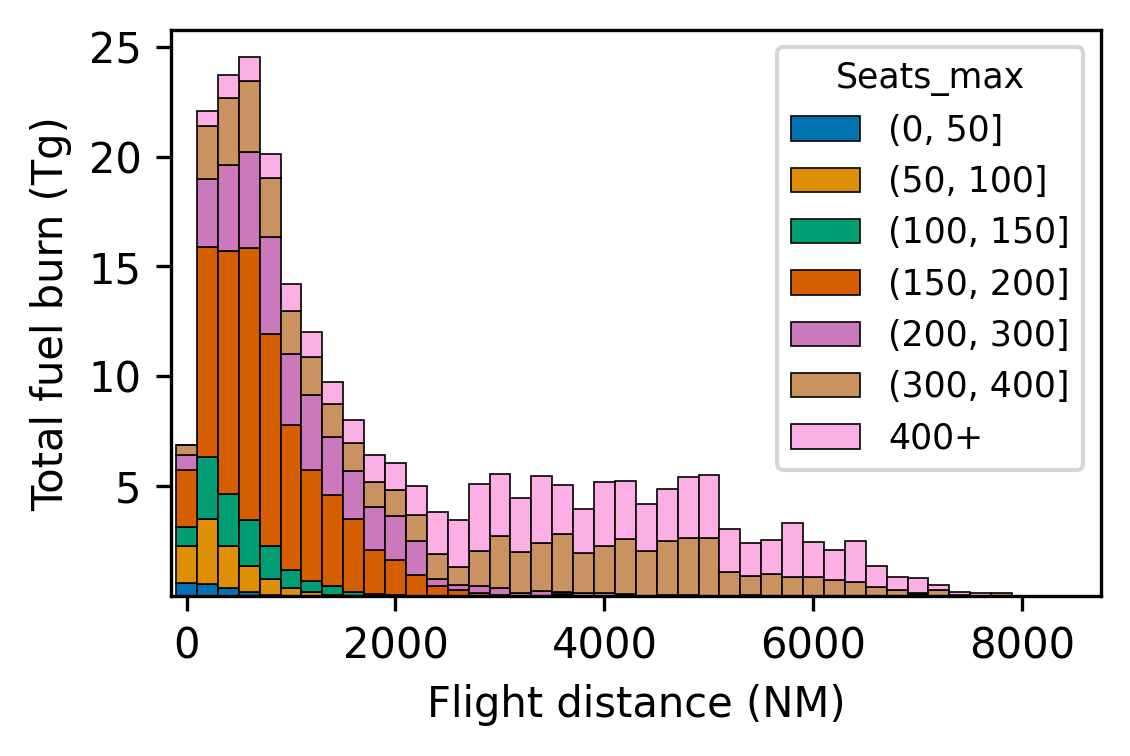

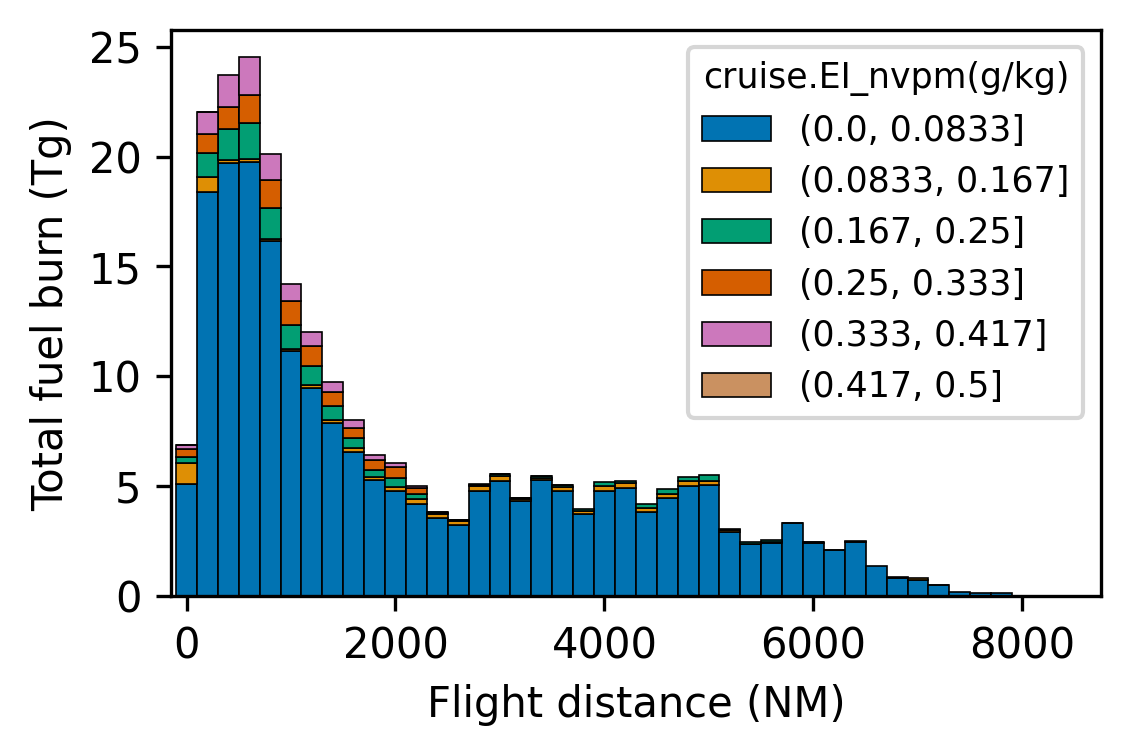

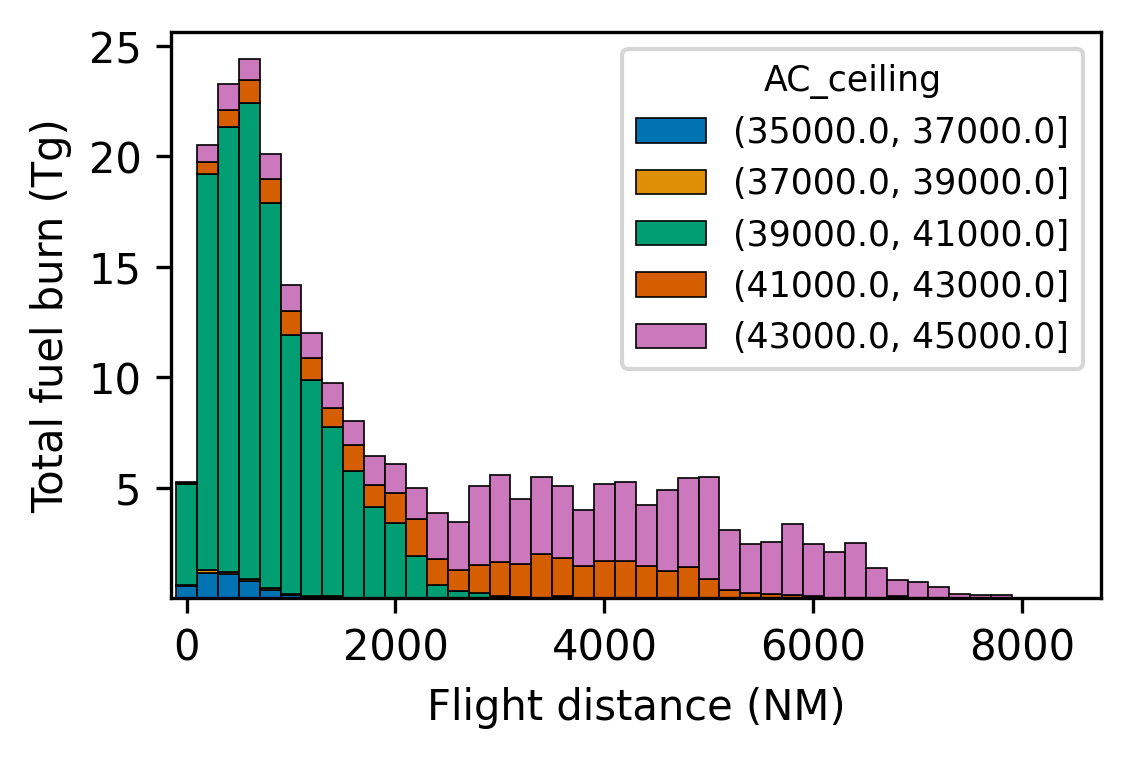

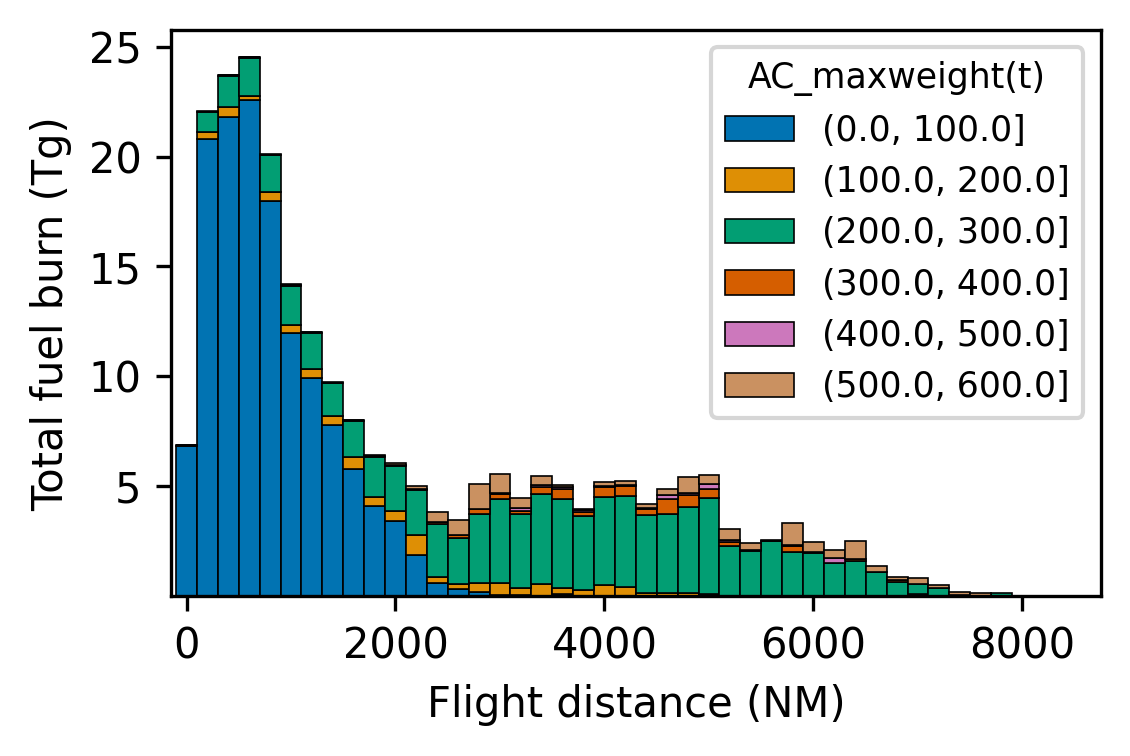

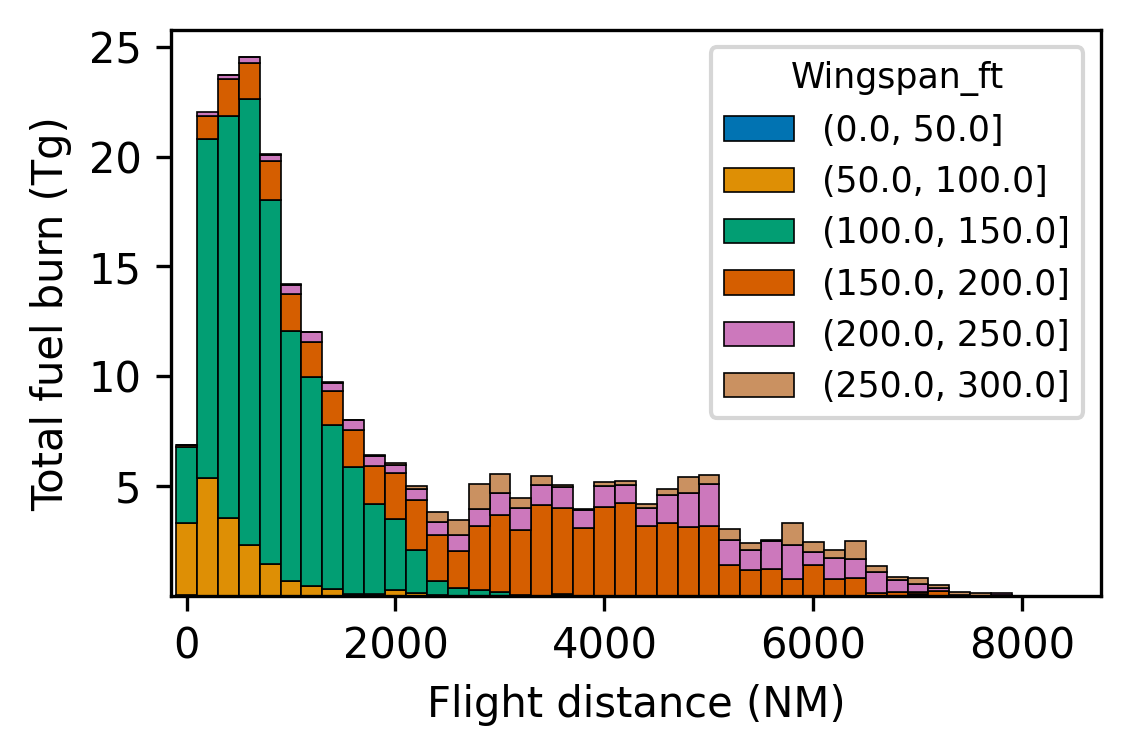

In [9]:
# yaxis_param_lst = ['fuel.per.flight(kg)', 'distance(nm)', 'PMnvol.per.flight(g)']
yaxis_param_lst = ['fuel.per.flight(kg)']

stacked_param_lst = ['Seats_max', 'cruise.EI_nvpm(g/kg)', 'AC_ceiling', 'AC_maxweight(t)','Wingspan_ft']
# stacked_param_lst = ['Seats_max']

yaxis_param_label_dict = {'fuel.per.flight(kg)': 'Total fuel burn (Tg)',
 'distance(nm)': 'Total distance (NM)', 
 'PMnvol.per.flight(g)': 'Total PM (g)'}

for stacked_param in stacked_param_lst:
    for yaxis_param in yaxis_param_lst:

        bins_vals_dist = list(range(0,9000,200))
        bins_number_dist = list(range(0,len(bins_vals_dist)))

        if stacked_param == 'Seats':
            bins_vals_seats = list(range(0,250,50)) + [300, 400, 2000]
        if stacked_param == 'Seats_max':
            bins_vals_seats = list(range(0,250,50)) + [300, 400, 2000]
        elif stacked_param =='cruise.EI_nvpm(g/kg)':
            bins_vals_seats = np.linspace(0,0.5,7)
        elif stacked_param == 'AC_ceiling':
            bins_vals_seats = np.linspace(35_000,45_000,6)
        elif stacked_param in ['AC_maxweight(t)', 'AC_minweight(t)', 'Max_payload(t)']:
            bins_vals_seats = np.linspace(0,600,7)
        elif stacked_param == 'Wingspan_ft':
            bins_vals_seats = np.linspace(0,300,7)
        else:
            bins_vals_seats = np.linspace(emissions_data[stacked_param].min(),emissions_data[stacked_param].max(),7)
            

        bins_vals_label = list(range(0,9000,2000))
        bins_vals_ticks = [i for i in range(0,len(bins_vals_dist)) if bins_vals_dist[i] in bins_vals_label]

        emissions_data['bucket_dist'] = pd.cut(emissions_data['distance(nm)'], bins = bins_vals_dist)
        emissions_data['bucket_seats'] = pd.cut(emissions_data[stacked_param], bins = bins_vals_seats)
        emissions_data['Seats_bins'] = emissions_data['Number.of.Operations']*emissions_data[yaxis_param]

        emissions_data_pt = 1e-9*emissions_data.pivot_table(index=['bucket_dist'], columns='bucket_seats',
                                                                    values='Seats_bins', aggfunc=sum)

        emissions_data_pt = emissions_data_pt.rename(columns={pd.Interval(400, 2000, closed='right'):'400+'})

        sns.set_palette("colorblind")

        fig, ax = plt.subplots(figsize=(4,2.5), dpi=300)
        emissions_data_pt.plot(kind='bar', width=1.0, edgecolor = 'k', linewidth=0.4,
                                stacked=True  , ax=ax )
                                

        ax.set_xticks(bins_vals_ticks,bins_vals_label)
        ax.tick_params(axis='x', labelrotation=0)

        ax.set_xlabel('Flight distance (NM)')
        ax.set_ylabel(f'{yaxis_param_label_dict[yaxis_param]}')
        lg = ax.legend(title=stacked_param, fontsize='small',
                        title_fontsize='small')

        plt.show()


### Now investigate data grouped by aircraft

In [10]:
case_name = '16_matched_engines_test'
OAG_Year = 2019
inp_mod  =''
output_loc = f'/net/d15/data/carlau/emisCli_io/{case_name}/aeic_out/forScheProc_out_{OAG_Year}{inp_mod}_{"Data_for_ChinaH"}.pkl'
emissions_data = pd.read_pickle(output_loc)

In [11]:
## all columns
# cols = [ 'Seats',
#             'distance(nm)',
#             'total.fuel(kg)', 
#             'inpacft_orig', 
#             'engine', 
#             'is_split', 
#             'Code', 
#             'Code.1',
#             'BADACode',
#             'BADAFlown', 
#             'AC_ceiling', 
#             'AC_minweight(t)', 
#             'AC_maxweight(t)', 
#             'AC_maxpayload(t)',
#             'Wingspan_ft', 
#             'cruise.EI_nvpm(g/kg)',
#            'cruise.EI_nvpm(g/kg)_mean', 
#            'total.fuel_frac', 
#            'total.distance_frac', 
#            'total.PMnvol_frac', 
#            'Seats_max']

cols = [ 'Aircraft.Type',
            'AC_ceiling', 
            'AC_minweight(t)',
            'AC_maxweight(t)', 
            'AC_maxpayload(t)',
            'Wingspan_ft', 
           'Seats_max',
           'cruise.EI_nvpm(g/kg)_mean', 
           'total.fuel_frac', 
           'total.distance_frac', 
           'total.PMnvol_frac',]



In [12]:
emissions_data_grpd = emissions_data.loc[:,cols].groupby([ 'Aircraft.Type',
            'AC_ceiling', 
            'AC_minweight(t)',
            'AC_maxweight(t)', 
            'AC_maxpayload(t)',
            'Wingspan_ft', 
           'Seats_max',
           'cruise.EI_nvpm(g/kg)_mean'], as_index=False).aggregate(sum).sort_values('total.fuel_frac', ascending=False)

emissions_data_grpd

,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac
577,77W_B773_GE90115B_DAC,43100.0,159.60,299.3,64.9,212.80,531.0,0.007374,8.517997e-02,4.481935e-02,1.173199e-02
33,320_A320_CFM565B43_TechInsertion,41000.0,39.00,77.0,21.5,111.88,302.0,0.026606,5.605837e-02,7.184546e-02,2.785939e-02
277,738_B738_CFM567B26E_TechInsertion,41000.0,41.15,78.3,20.3,112.58,189.0,0.024068,3.373717e-02,4.120857e-02,1.516701e-02
40,320_A320_V2527A5SelectOneUpgradePackage_Floatwall,41000.0,39.00,77.0,21.5,111.88,189.0,0.319611,2.888900e-02,3.706857e-02,1.724699e-01
193,388_A388_GP7270_nan,43100.0,295.00,560.0,91.0,261.65,615.0,0.017535,2.609425e-02,9.286774e-03,8.546714e-03
...,...,...,...,...,...,...,...,...,...,...,...
198,727,42000.0,45.40,86.4,18.1,108.00,172.0,0.113942,8.427200e-08,5.789982e-08,1.793607e-07
446,75T_B753_PW2040_nan,43000.0,64.59,122.5,30.7,124.83,275.0,0.036494,8.375433e-08,7.503414e-08,5.709412e-08
445,75T_B753_PW2037_nan,43000.0,64.59,122.5,30.7,124.83,275.0,0.034441,8.350147e-08,7.503414e-08,5.371990e-08
93,32S_A319_CFM565A4_nan,41000.0,40.00,70.0,17.0,111.88,144.0,0.052521,6.580185e-08,9.332115e-08,6.455502e-08


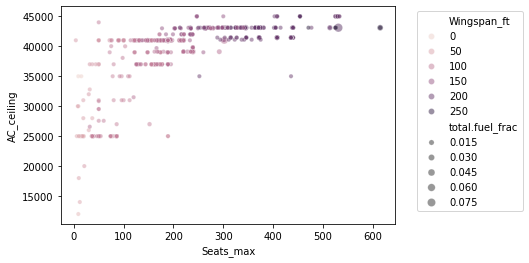

In [13]:
## Make scatter plots of the aircraft types
fig, ax = plt.subplots()
x_param = 'Seats_max'
yaxis_param = 'AC_ceiling'
hue_param = 'Wingspan_ft'
size_param = 'total.fuel_frac'

sns.scatterplot(data=emissions_data_grpd, x=x_param, y=yaxis_param, hue=hue_param, size = size_param,alpha=0.5, ax=ax)
# set legend outside of the plot

ax.legend(bbox_to_anchor=(1.05, 1), loc=2)


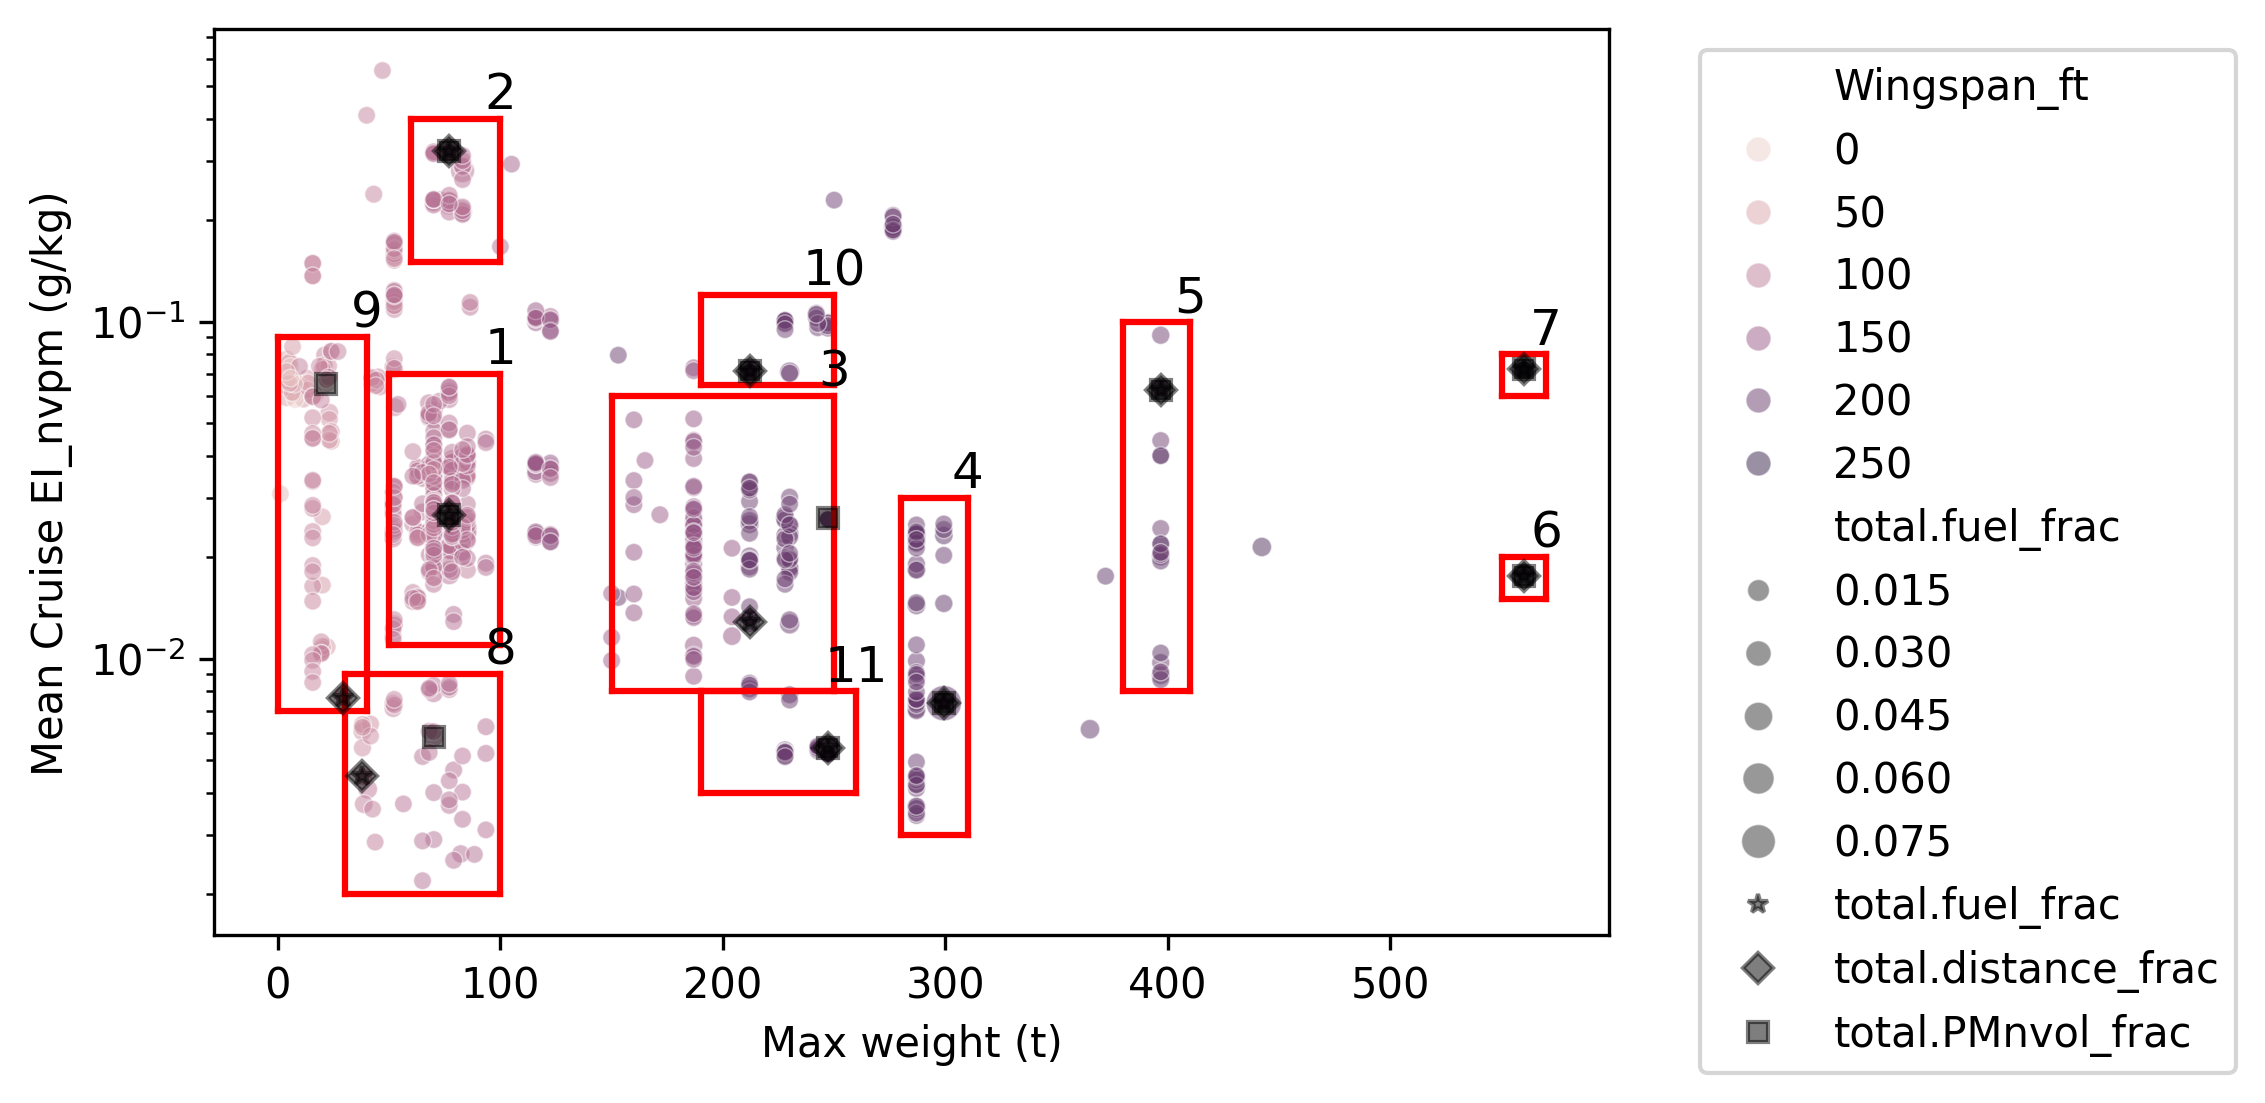

In [14]:
## Make scatter plots of the aircraft types
fig, ax = plt.subplots(dpi=300)
is_baseplot_only = 0
x_param = 'AC_maxweight(t)'
yaxis_param ='cruise.EI_nvpm(g/kg)_mean'
hue_param = 'Wingspan_ft'
size_param = 'total.fuel_frac'

sns.scatterplot(data=emissions_data_grpd, x=x_param, y=yaxis_param, hue=hue_param, size = size_param,alpha=0.5, ax=ax)
# set legend outside of the plot

# sns.scatterplot(data=emissions_data_grpd_sugAC, x=x_param, y=yaxis_param, color='k', style='Aircraft.Type', s=100, ax=ax)
# emissions_data_grpd_sugAC.plot.scatter(x=x_param, y=yaxis_param, color='k', marker='Aircraft.Type', s=100, ax=ax)
ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
ax.set_yscale('log')

if is_baseplot_only == 0:
    clusters_dict = {1: {'max_weight_lims': [50, 100], 'EI_nvpm_lims': [1.1e-2, 0.7e-1]},
                    2: {'max_weight_lims': [60, 100], 'EI_nvpm_lims': [1.5e-1, 4e-1]},
                    3: {'max_weight_lims': [150, 250], 'EI_nvpm_lims': [0.8e-2, 0.6e-1]},
                    4: {'max_weight_lims': [280, 310], 'EI_nvpm_lims': [3e-3, 3e-2]},
                    5: {'max_weight_lims': [380, 410], 'EI_nvpm_lims': [8e-3, 1e-1]},
                    6: {'max_weight_lims': [550, 570], 'EI_nvpm_lims': [1.5e-2, 2e-2]},
                    7: {'max_weight_lims': [550, 570], 'EI_nvpm_lims': [6e-2, 8e-2]},
                    8: {'max_weight_lims': [30, 100], 'EI_nvpm_lims': [2e-3, 9e-3]},
                    9: {'max_weight_lims': [0, 40], 'EI_nvpm_lims': [7e-3, 9e-2]},
                    10: {'max_weight_lims': [190, 250], 'EI_nvpm_lims': [6.5e-2, 1.2e-1]},
                    11: {'max_weight_lims': [190, 260], 'EI_nvpm_lims': [4e-3, 0.8e-2]}
                    }

    # create a dataframe with info for each cluster
    columns = ['max_weight_min', 'max_weight_max', 'EI_nvpm_min', 'EI_nvpm_max',
            'total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac']

    cluster_df = pd.DataFrame(columns=columns)
    emissions_data_grpd['cluster'] = np.nan

    for cluster in clusters_dict:
        # add clusters to the graph
        max_weight_lims = clusters_dict[cluster]['max_weight_lims']
        EI_nvpm_lims = clusters_dict[cluster]['EI_nvpm_lims']

        # add the cluster to the emissions_data_grpd dataframe
        locs = ((emissions_data_grpd['AC_maxweight(t)'] > max_weight_lims[0]) &
                            (emissions_data_grpd['AC_maxweight(t)'] < max_weight_lims[1])&
                            (emissions_data_grpd['cruise.EI_nvpm(g/kg)_mean'] > EI_nvpm_lims[0]) &
                            (emissions_data_grpd['cruise.EI_nvpm(g/kg)_mean'] < EI_nvpm_lims[1]))

        emissions_data_grpd.loc[locs, 'cluster'] = cluster

        # fraction of fuel burn in this range
        temp_df = (emissions_data_grpd[locs].aggregate(sum))

        cluster_df.loc[cluster, 'max_weight_min'] = max_weight_lims[0]
        cluster_df.loc[cluster, 'max_weight_max'] = max_weight_lims[1]
        cluster_df.loc[cluster, 'EI_nvpm_min'] = EI_nvpm_lims[0]
        cluster_df.loc[cluster, 'EI_nvpm_max'] = EI_nvpm_lims[1]
        cluster_df.loc[cluster, 'total.fuel_frac'] = temp_df['total.fuel_frac']
        cluster_df.loc[cluster, 'total.distance_frac'] = temp_df['total.distance_frac']
        cluster_df.loc[cluster, 'total.PMnvol_frac'] = temp_df['total.PMnvol_frac']
        

        # plot the bounding box of the max_weight_lims and EI_nvpm_lims
        xmin, xmax = max_weight_lims
        ymin, ymax = EI_nvpm_lims
        ax.plot([xmin, xmax], [ymin, ymin], 'r-')  # Left side
        ax.plot([xmax, xmax], [ymin, ymax], 'r-')  # Right side
        ax.plot([xmin, xmax], [ymax, ymax], 'r-')  # Top side
        ax.plot([xmin, xmin], [ymin, ymax], 'r-')  # Bottom side

        # add label top right just outside the cluster on the plot
        # ax.text(xmax + 10, ymax, 'Cluster {}'.format(cluster), fontsize=12)
        ax.text((xmax), (ymax), str(cluster), fontsize=12, ha='center', va='bottom')

        ax.set_xlabel('Max weight (t)')
        ax.set_ylabel('Mean Cruise EI_nvpm (g/kg)')


        # plot the aircraft with the highest contribution
        marker_dict = {'total.fuel_frac':'*', 'total.distance_frac':'D', 'total.PMnvol_frac':'s'}
        for var in ['total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac']:
            emit_tmp = emissions_data_grpd[emissions_data_grpd['cluster']==cluster].sort_values(var, ascending=False).head(1)
            marker_1 = ax.plot(emit_tmp['AC_maxweight(t)'], emit_tmp['cruise.EI_nvpm(g/kg)_mean'], c='k', marker=marker_dict[var], markersize=5, linestyle='None', label=var, alpha=0.5)

            if cluster == 1:
                legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
                handles, labels = legend.legendHandles, legend.get_texts()

                new_handles = [marker_1]
                new_labels = [var]

                all_handles = handles + new_handles
                all_labels = [label.get_text() for label in labels] + new_labels

                ax.legend(all_handles, all_labels,bbox_to_anchor=(1.05, 1), loc=2) 

        ax.legend(all_handles, all_labels,bbox_to_anchor=(1.05, 1), loc=2) 


plt.show()


In [15]:
for cluster in clusters_dict:
    display(emissions_data_grpd[emissions_data_grpd['cluster']==cluster].sort_values('total.fuel_frac', ascending=False).head(10))

,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
33,320_A320_CFM565B43_TechInsertion,41000.0,39.00,77.00,21.50,111.88,302.0,0.026606,0.056058,0.071845,0.027859,1.0
277,738_B738_CFM567B26E_TechInsertion,41000.0,41.15,78.30,20.30,112.58,189.0,0.024068,0.033737,0.041209,0.015167,1.0
322,73H_B738_CFM567B26E_TechInsertion,41000.0,41.15,78.30,20.30,117.42,189.0,0.023862,0.022984,0.028193,0.010244,1.0
278,738_B738_CFM567B26_nan,41000.0,41.15,78.30,20.30,112.58,189.0,0.035690,0.015765,0.019551,0.010510,1.0
48,321_A321_CFM565B33_TechInsertion,39100.0,47.80,83.00,21.70,111.88,292.0,0.037936,0.013664,0.016237,0.009683,1.0
274,738_B738_CFM567B24E_TechInsertion,41000.0,41.15,78.30,20.30,112.58,189.0,0.021059,0.012578,0.015112,0.004948,1.0
34,320_A320_CFM565B4P_nan,41000.0,39.00,77.00,21.50,111.88,212.0,0.017803,0.012199,0.015806,0.004057,1.0
387,73W_B737_CFM567B22_nan,41000.0,38.10,70.08,16.92,117.42,148.0,0.034406,0.012049,0.014829,0.007743,1.0
321,73H_B738_CFM567B263_TechInsertion,41000.0,41.15,78.30,20.30,117.42,189.0,0.036677,0.011972,0.014685,0.008202,1.0
276,738_B738_CFM567B263_TechInsertion,41000.0,41.15,78.30,20.30,112.58,189.0,0.036826,0.011937,0.014488,0.008211,1.0


,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
40,320_A320_V2527A5SelectOneUpgradePackage_Floatwall,41000.0,39.0,77.0,21.5,111.88,189.0,0.319611,0.028889,0.037069,0.172470,2.0
52,321_A321_V2533A5SelectOneUpgradePackage_Floatwall,39100.0,47.8,83.0,21.7,111.88,239.0,0.280271,0.024316,0.028404,0.127298,2.0
41,320_A320_V2527A5_nan,41000.0,39.0,77.0,21.5,111.88,220.0,0.224078,0.018930,0.024398,0.079235,2.0
53,321_A321_V2533A5_nan,39100.0,47.8,83.0,21.7,111.88,239.0,0.211503,0.006046,0.006869,0.023887,2.0
27,319_A319_V2524A5_nan,41000.0,40.0,70.0,17.0,111.88,174.0,0.225364,0.004993,0.006296,0.021017,2.0
75,32B_A321_V2533A5SelectOneUpgradePackage_Floatwall,39100.0,47.8,83.0,21.7,117.45,228.0,0.288404,0.004439,0.005460,0.023916,2.0
63,32A_A320_V2527A5SelectOneUpgradePackage_Floatwall,41000.0,39.0,77.0,21.5,117.45,186.0,0.317250,0.003998,0.005165,0.023689,2.0
25,319_A319_V2522A5_nan,41000.0,40.0,70.0,17.0,111.88,174.0,0.226463,0.003296,0.004159,0.013941,2.0
39,320_A320_V2527A5ESelectOneUpgradePackage_Float...,41000.0,39.0,77.0,21.5,111.88,186.0,0.320088,0.002685,0.003632,0.016053,2.0
42,320_A320_V2527EA5_nan,41000.0,39.0,77.0,21.5,111.88,220.0,0.222885,0.001225,0.001627,0.005099,2.0


,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
179,333_A333_Trent772_nan,41450.0,125.10,212.00,47.900,197.83,408.0,0.012857,0.014840,0.010382,0.003564,3.0
624,789_B789_Trent1000J2_Phase5Tiled,43100.0,110.66,247.20,63.638,197.25,375.0,0.026046,0.008424,0.006430,0.004099,3.0
165,332_A332_Trent772_nan,41450.0,120.60,230.00,47.400,197.83,372.0,0.012676,0.008401,0.006326,0.001989,3.0
615,788_B788_Trent1000G2_Phase5Tiled,43100.0,111.49,227.93,43.091,197.25,325.0,0.026106,0.004908,0.003695,0.002393,3.0
157,332_A332_CF680E1A3_Standard,41450.0,120.60,230.00,47.400,197.83,372.0,0.024846,0.004096,0.002868,0.001901,3.0
166,333_A333_CF680E1A3_Standard,41450.0,125.10,212.00,47.900,197.83,408.0,0.025033,0.003573,0.002544,0.001671,3.0
484,764_B764_CF680C2B8F_1862M39,45000.0,103.20,204.10,46.500,156.08,247.0,0.011659,0.003450,0.002406,0.000751,3.0
169,333_A333_PW4168A1D_TalonIIB,41450.0,125.10,212.00,47.900,197.83,408.0,0.018761,0.003188,0.002142,0.001117,3.0
159,332_A332_CF680E1A4_Standard,41450.0,120.60,230.00,47.400,197.83,372.0,0.023520,0.003146,0.002312,0.001382,3.0
158,332_A332_CF680E1A4_Lowemissions,41450.0,120.60,230.00,47.400,197.83,372.0,0.018465,0.003102,0.002296,0.001070,3.0


,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
577,77W_B773_GE90115B_DAC,43100.0,159.6,299.3,64.9,212.80,531.0,0.007374,0.085180,0.044819,0.011732,4.0
549,773_B773_GE90115B_DAC,43100.0,159.6,299.3,64.9,199.92,514.0,0.007457,0.017757,0.009418,0.002473,4.0
570,777_B773_GE90115B_DAC,43100.0,159.6,299.3,64.9,199.92,381.0,0.007446,0.005653,0.003052,0.000786,4.0
547,772_B772_Trent892_nan,43100.0,138.1,287.0,56.9,199.92,440.0,0.023240,0.005651,0.003358,0.002453,4.0
572,77L_B772_GE90110B1_DAC,43100.0,138.1,287.0,56.9,212.58,315.0,0.007091,0.004433,0.002628,0.000587,4.0
537,772_B772_GE9094B_DACII,43100.0,138.1,287.0,56.9,199.92,440.0,0.018335,0.003724,0.002178,0.001275,4.0
538,772_B772_GE9094B_PEC,43100.0,138.1,287.0,56.9,199.92,440.0,0.003641,0.003720,0.002182,0.000253,4.0
566,777_B772_PW4090_Floatwall,43100.0,138.1,287.0,56.9,199.92,364.0,0.014379,0.003303,0.002034,0.000887,4.0
569,777_B772_Trent895_nan,43100.0,138.1,287.0,56.9,199.92,336.0,0.022213,0.002880,0.001689,0.001195,4.0
579,77W_B773_Trent892_nan,43100.0,159.6,299.3,64.9,212.80,402.0,0.023187,0.002769,0.001531,0.001199,4.0


,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
408,744_B744_RB211524H_nan,45000.0,180.44,396.8,67.3,195.67,408.0,0.062479,0.002947,0.001331,0.003440,5.0
401,744_B744_CF680C2B1F_nan,45000.0,180.44,396.8,67.3,195.67,525.0,0.020065,0.002912,0.001289,0.001091,5.0
400,744_B744_CF680C2B1F_LEC,45000.0,180.44,396.8,67.3,195.67,525.0,0.008918,0.002849,0.001250,0.000475,5.0
407,744_B744_RB211524HT_nan,45000.0,180.44,396.8,67.3,195.67,408.0,0.091076,0.001878,0.000866,0.003195,5.0
402,744_B744_CF680C2B5F_LEC,45000.0,180.44,396.8,67.3,195.67,529.0,0.009731,0.001404,0.000555,0.000255,5.0
414,74E_B744_CF680C2B1F_nan,45000.0,180.44,396.8,67.3,213.00,454.0,0.019479,0.000630,0.000275,0.000229,5.0
413,74E_B744_CF680C2B1F_LEC,45000.0,180.44,396.8,67.3,213.00,454.0,0.008667,0.000629,0.000278,0.000102,5.0
406,744_B744_RB211524G_nan,45000.0,180.44,396.8,67.3,195.67,403.0,0.063474,0.000501,0.000234,0.000595,5.0
411,747_B744_PW4056_Reducedsmoke,45000.0,180.44,396.8,67.3,195.67,529.0,0.021870,0.000464,0.000190,0.000190,5.0
412,747_B744_PW4056_nan,45000.0,180.44,396.8,67.3,195.67,529.0,0.040100,0.000461,0.000191,0.000345,5.0


...

,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
194,388_A388_Trent97084_Phase5Tiled,43100.0,295.0,560.0,91.0,261.65,526.0,0.072207,0.010455,0.003824,0.014101,7.0
195,388_A388_Trent97284_Phase5Tiled,43100.0,295.0,560.0,91.0,261.65,615.0,0.071931,0.006189,0.002192,0.008316,7.0
192,380_A388_Trent97084_Phase5Tiled,43100.0,295.0,560.0,91.0,261.65,525.0,0.071950,0.001912,0.000669,0.002570,7.0


,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
675,CR9_CRJ9_CF348C5_LEC,41000.0,22.200,38.00,9.900,81.5800,90.0,0.004495,0.007100,0.011501,0.000596,8.0
726,E75,41000.0,21.890,40.37,10.110,103.9200,100.0,0.004098,0.006629,0.011381,0.000507,8.0
19,319_A319_CFM565B5P_nan,41000.0,40.000,70.00,17.000,111.8800,174.0,0.005839,0.006232,0.007992,0.000680,8.0
22,319_A319_CFM565B6P_nan,41000.0,40.000,70.00,17.000,111.8800,174.0,0.007895,0.004364,0.005607,0.000644,8.0
673,CR7,41000.0,22.200,38.00,9.900,76.0000,72.0,0.006083,0.004207,0.006627,0.000478,8.0
727,E7W,41000.0,21.141,38.60,9.759,94.1700,76.0,0.003701,0.003902,0.007028,0.000270,8.0
725,E70,41000.0,21.141,38.60,9.759,85.3300,100.0,0.004449,0.002612,0.004207,0.000217,8.0
628,7M8,41000.0,42.638,82.19,23.314,117.7822,197.0,0.002633,0.002215,0.003423,0.000109,8.0
740,E90_E190_CF3410E6_SAC,41000.0,27.837,51.80,13.063,94.2500,131.0,0.007112,0.001575,0.002266,0.000209,8.0
680,CRJ_CRJ9_CF348C5_LEC,41000.0,22.200,38.00,9.900,81.5800,90.0,0.005435,0.001492,0.002312,0.000151,8.0


,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
704,DH4_DH8D_PW815GA_TALONX,27000.0,17.604,29.257,8.251,90.00,152.0,0.007624,0.004544,0.007279,0.000647,9.0
656,AT7,25000.0,12.300,21.500,7.400,80.42,78.0,0.065356,0.003249,0.007230,0.003966,9.0
678,CRJ_CRJ2_CF343B3B1_SAC,41000.0,14.860,23.130,5.140,81.58,90.0,0.053712,0.002634,0.005729,0.002642,9.0
763,ER4,37000.0,12.114,22.000,5.786,65.75,50.0,0.010828,0.002295,0.004784,0.000464,9.0
765,ERJ,37000.0,11.501,19.990,4.499,65.75,50.0,0.010651,0.001342,0.002997,0.000267,9.0
720,DH8_DH8D_PW815GA_TALONX,27000.0,17.604,29.257,8.251,90.00,86.0,0.007806,0.001218,0.001920,0.000178,9.0
657,ATR,25000.0,12.850,22.000,7.150,80.42,189.0,0.067066,0.001041,0.002236,0.001304,9.0
703,DH3_DH8C_PW1923G_TALONX_BlockC,25000.0,11.763,19.500,6.100,90.00,54.0,0.010483,0.000690,0.001165,0.000135,9.0
764,ERD,37000.0,11.501,19.990,4.499,65.75,44.0,0.010854,0.000669,0.001426,0.000136,9.0
667,CNC,25000.0,2.048,3.969,1.808,50.00,14.0,0.077441,0.000425,0.004319,0.000615,9.0


,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
178,333_A333_Trent772_Phase5,41450.0,125.10,212.00,47.900,197.8300,408.0,0.071303,0.014761,0.010359,0.019659,10.0
164,332_A332_Trent772_Phase5,41450.0,120.60,230.00,47.400,197.8300,372.0,0.070838,0.008427,0.006334,0.011150,10.0
625,789_B789_Trent1000J3_Phase5Tiled,43100.0,110.66,247.20,63.638,197.2500,375.0,0.099004,0.004272,0.003247,0.007901,10.0
151,330_A333_Trent772_Phase5,41450.0,125.10,212.00,47.900,197.8300,440.0,0.071048,0.002362,0.001779,0.003135,10.0
613,788_B788_Trent1000CE3_Phase5Tiled,43100.0,111.49,227.93,43.091,197.2500,335.0,0.099532,0.002000,0.001596,0.003718,10.0
137,330_A332_Trent772_Phase5,41450.0,120.60,230.00,47.400,197.8300,436.0,0.070230,0.001627,0.001367,0.002135,10.0
180,339_A339_Trent700072_Phase5Tiled,41450.0,138.06,242.00,38.937,197.8346,440.0,0.105651,0.001393,0.000972,0.002748,10.0
602,787_B78X_Trent1000M3_Phase5Tiled,41100.0,126.35,242.67,75.794,197.2500,337.0,0.095963,0.001066,0.000716,0.001910,10.0
612,788_B788_Trent1000AE3_Phase5Tiled,43100.0,111.49,227.93,43.091,197.2500,305.0,0.100818,0.000467,0.000371,0.000880,10.0
599,787_B789_Trent1000J3_Phase5Tiled,43100.0,110.66,247.20,63.638,197.2500,477.0,0.095590,0.000348,0.000245,0.000621,10.0


,Aircraft.Type,AC_ceiling,AC_minweight(t),AC_maxweight(t),AC_maxpayload(t),Wingspan_ft,Seats_max,cruise.EI_nvpm(g/kg)_mean,total.fuel_frac,total.distance_frac,total.PMnvol_frac,cluster
620,789_B789_GEnx1B7475P2_TAPS,43100.0,110.66,247.20,63.638,197.2500,345.0,0.005446,0.024986,0.018877,0.002542,11.0
610,788_B788_GEnx1B70P2_TAPS,43100.0,111.49,227.93,43.091,197.2500,325.0,0.005341,0.004000,0.003134,0.000399,11.0
608,788_B788_GEnx1B7075P2_TAPS,43100.0,111.49,227.93,43.091,197.2500,325.0,0.005273,0.003422,0.002747,0.000337,11.0
606,788_B788_GEnx1B67P2_TAPS,43100.0,111.49,227.93,43.091,197.2500,325.0,0.005230,0.002383,0.001825,0.000233,11.0
604,788_B788_GEnx1B64P2_TAPS,43100.0,111.49,227.93,43.091,197.2500,335.0,0.005156,0.001617,0.001278,0.000156,11.0
596,787_B789_GEnx1B7475P2_TAPS,43100.0,110.66,247.20,63.638,197.2500,357.0,0.005263,0.001410,0.001034,0.000139,11.0
621,789_B789_GEnx1B76AP2_TAPS,43100.0,110.66,247.20,63.638,197.2500,345.0,0.005489,0.001203,0.000914,0.000123,11.0
161,332_A332_PW4168A_Floatwall,41450.0,120.60,230.00,47.400,197.8300,372.0,0.007809,0.000929,0.000640,0.000136,11.0
582,781_B78X_GEnx1B76P2_TAPS,41100.0,126.35,242.67,75.794,197.1785,342.0,0.005386,0.000842,0.000580,0.000085,11.0
585,787_B788_GEnx1B64P2_TAPS,43100.0,111.49,227.93,43.091,197.2500,335.0,0.005254,0.000641,0.000521,0.000063,11.0


In [16]:
# print out total fractions covered by the clusters
cluster_df.aggregate(sum)

max_weight_min             2430
max_weight_max             2960
EI_nvpm_min               0.333
EI_nvpm_max               0.987
total.fuel_frac        0.959755
total.distance_frac    0.968659
total.PMnvol_frac      0.943544
dtype: object

### Make plots of the nvPM of each flight by aircraft and distance

In [17]:
ac_lst = emissions_data[['Aircraft.Type', f'{var}']].groupby('Aircraft.Type').aggregate(sum).sort_values(f'{var}', ascending=False)[:30].index.tolist()
ac_lst

emissions_data_red = emissions_data[emissions_data['Aircraft.Type'].isin(ac_lst)]

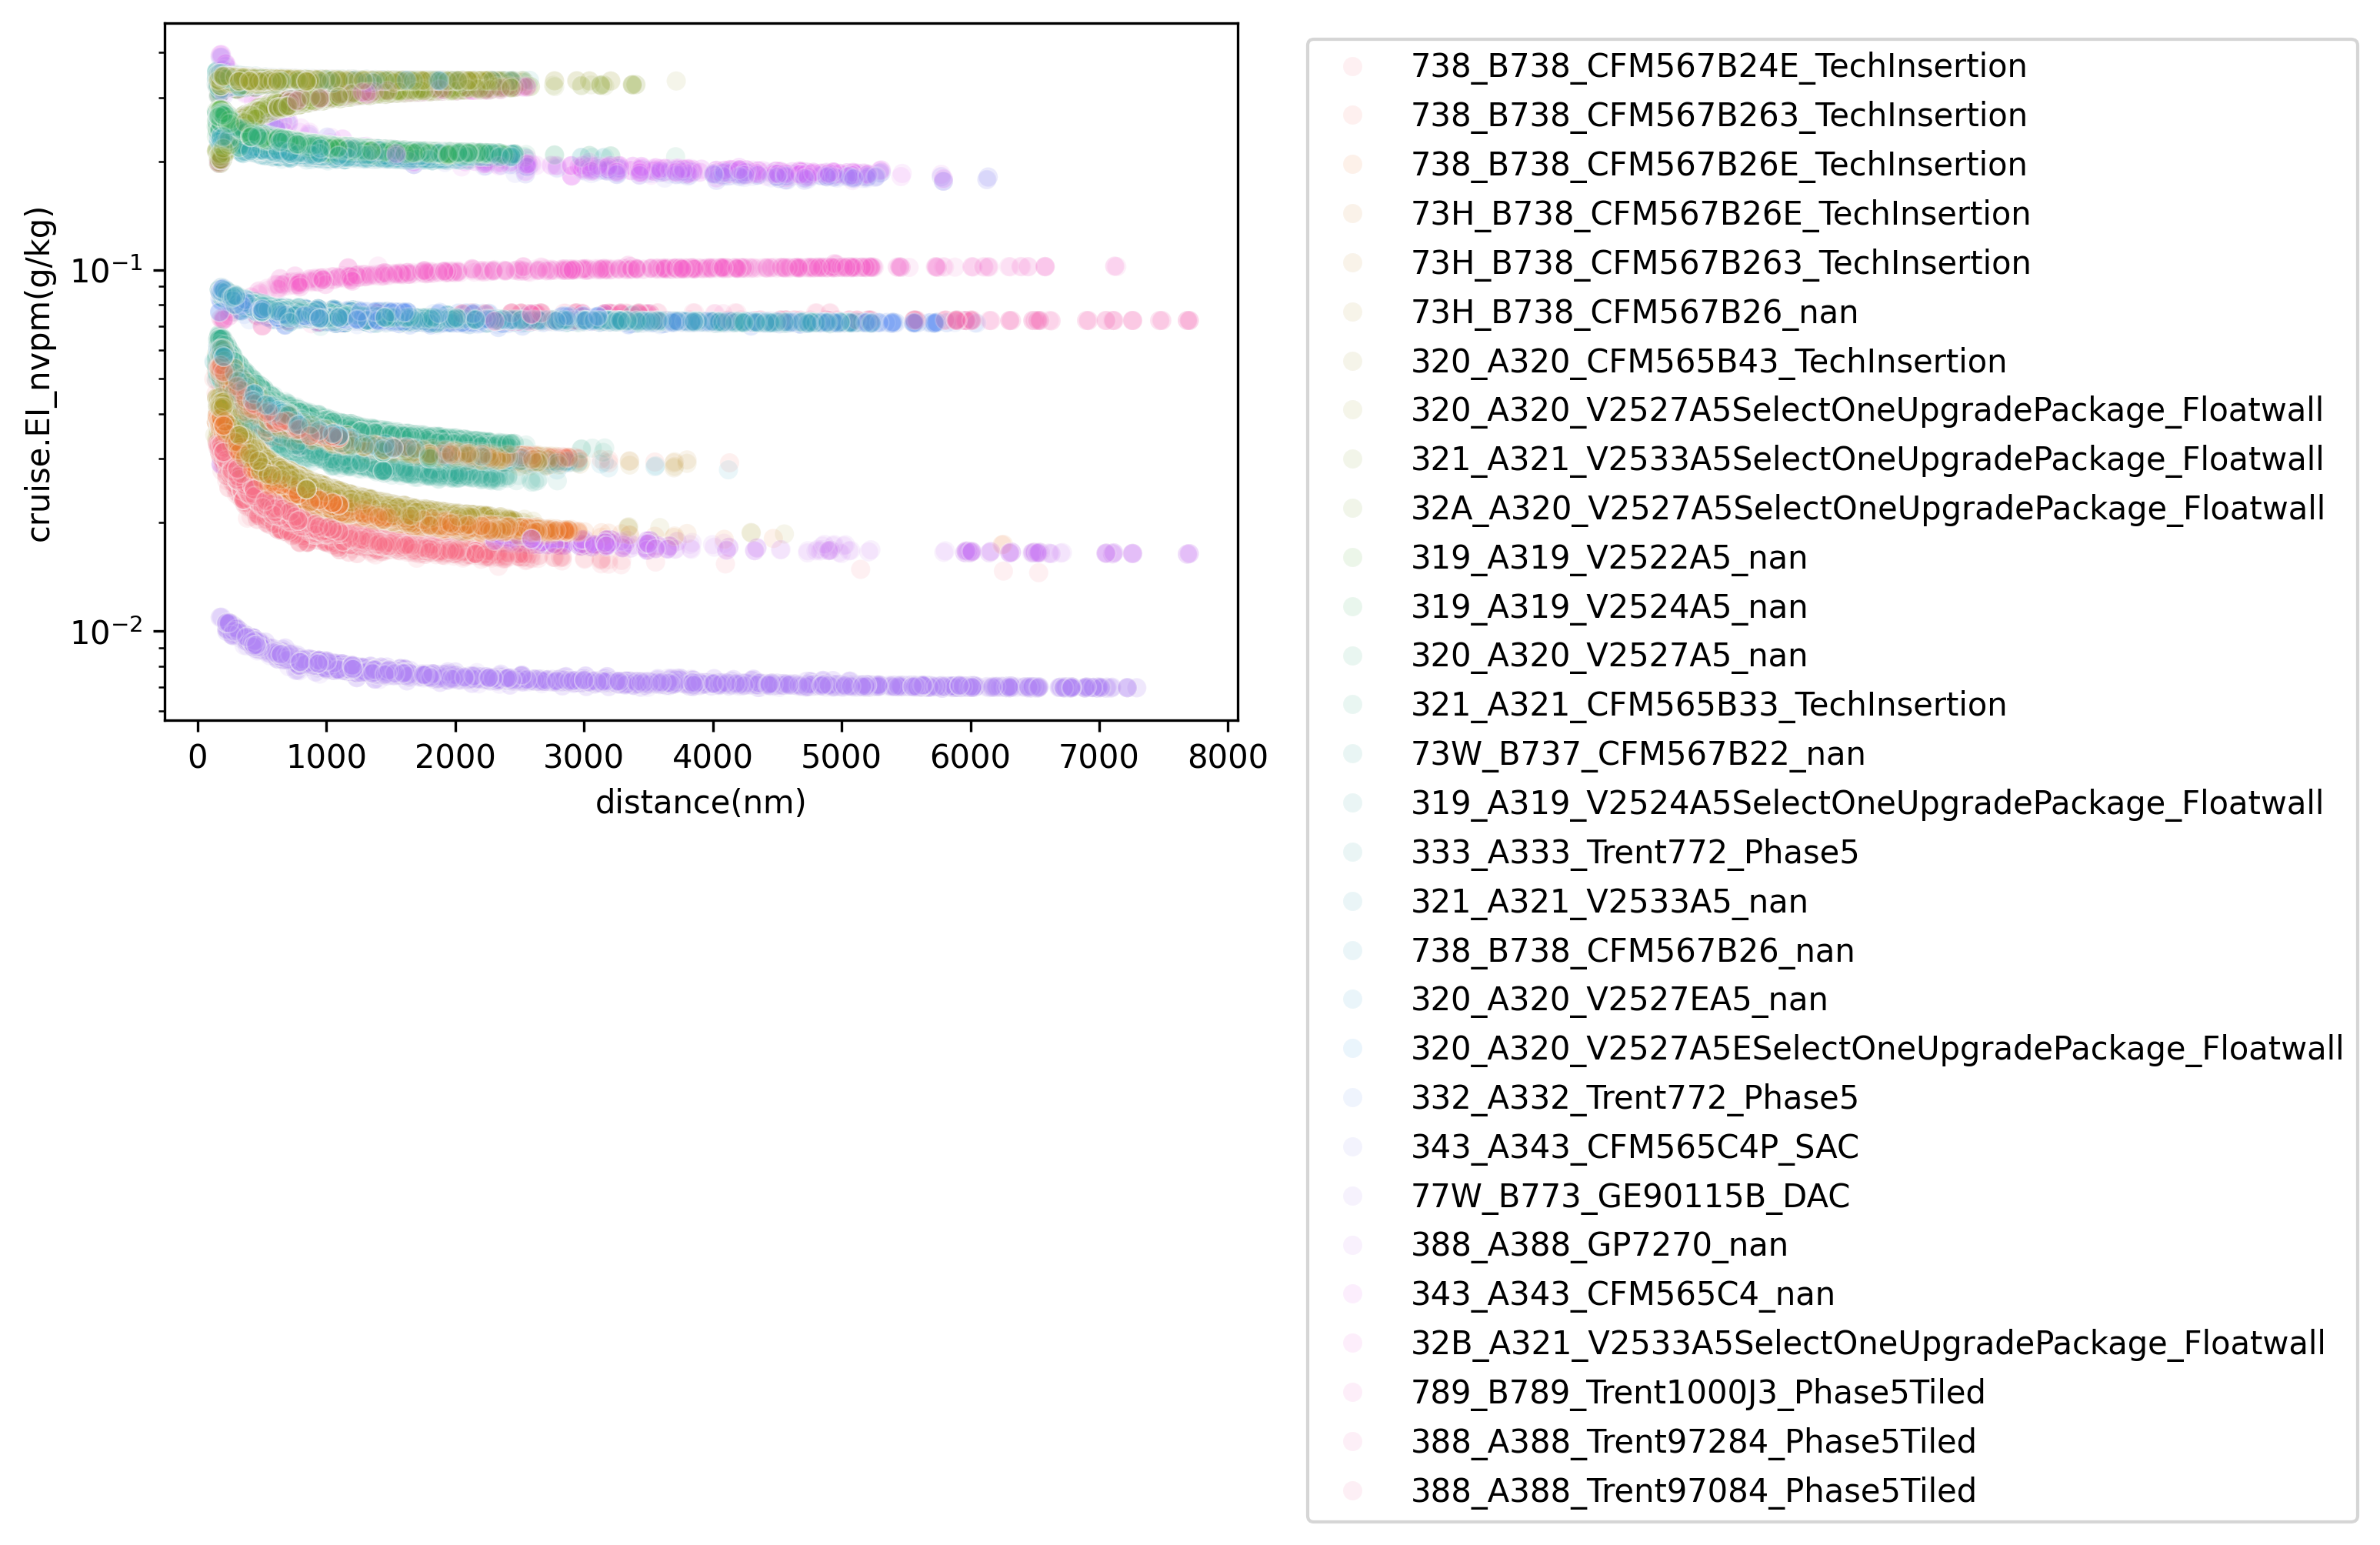

In [18]:
## Make scatter plots of the aircraft types
fig, ax = plt.subplots(dpi=300)

# sns.scatterplot(data=emissions_data_red_red, x='cruise.EI_nvpm(g/kg)', y='distance(nm)', hue='Aircraft.Type', alpha=0.1, ax=ax)
sns.scatterplot(data=emissions_data_red, x='distance(nm)', y='cruise.EI_nvpm(g/kg)', hue='Aircraft.Type', alpha=0.1, ax=ax)
ax.set_yscale('log')


# set legend outside of the plot
ax.legend(bbox_to_anchor=(1.05, 1), loc=2)

## Further cleaning up and consolidating aircraft types (renaming)

In [ ]:
# Filter out any aircraft that have columns containing NaN values
emissions_data_grpd = emissions_data_grpd.dropna()

# Create a dictionary to store the aircraft names based on the criteria
aircraft_dict = {}

# Iterate through the aircraft names
for aircraft in emissions_data_grpd['Aircraft.Type']:
    parts = aircraft.split('_')
    if len(parts) > 2:
        key = (parts[1], parts[2])
        if key in aircraft_dict:
            aircraft_dict[key].append(aircraft)
        else:
            aircraft_dict[key] = [aircraft]

# Print the aircraft names that meet the criteria
for key, aircraft_list in aircraft_dict.items():
    if len(aircraft_list) > 1:

        # Combine the rows of the entries that are stored in aircraft_list
        for aircraft_list in aircraft_dict.values():
            if len(aircraft_list) > 1:
                # Filter the rows corresponding to the aircraft_list
                filtered_aircraft = emissions_data_grpd[emissions_data_grpd['Aircraft.Type'].isin(aircraft_list)]
                
                if not filtered_aircraft.empty:
                    # Sum the columns total.fuel_frac, total.distance_frac, total.PMnvol_frac
                    summed_row = filtered_aircraft[['total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac']].sum()
                    
                    # Get the row with the highest total.fuel_frac
                    max_fuel_row = filtered_aircraft.loc[filtered_aircraft['total.fuel_frac'].idxmax()]
                    
                    # Use the values from the row with the highest fuel_frac for other columns
                    combined_row = max_fuel_row.copy()
                    combined_row[['total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac']] = summed_row
                    
                    # Rename the aircraft
                    parts = aircraft_list[0].split('_')
                    new_name = '_'.join(parts[1:3]) if len(parts) > 2 else parts[0]
                    combined_row['Aircraft.Type'] = new_name
                    
                    # Append the combined row to the dataframe using pd.concat
                    emissions_data_grpd = pd.concat([emissions_data_grpd, combined_row.to_frame().T], ignore_index=True)
                    
                    # Drop the original rows
                    emissions_data_grpd = emissions_data_grpd[~emissions_data_grpd['Aircraft.Type'].isin(aircraft_list)]


# Clean up the aircraft names, specifically
for i, row in emissions_data_grpd.iterrows():
    aircraft_type = row['Aircraft.Type']
    parts = aircraft_type.split('_')
    if len(parts) > 2:
        label = '_'.join(parts[1:3])
    else:
        label = aircraft_type
    label = label.replace('_', ' ').replace('SelectOneUpgradePackage', '')
    emissions_data_grpd.loc[emissions_data_grpd['Aircraft.Type'] == aircraft_type, 'Aircraft.Type'] = label


## Plot Clusters

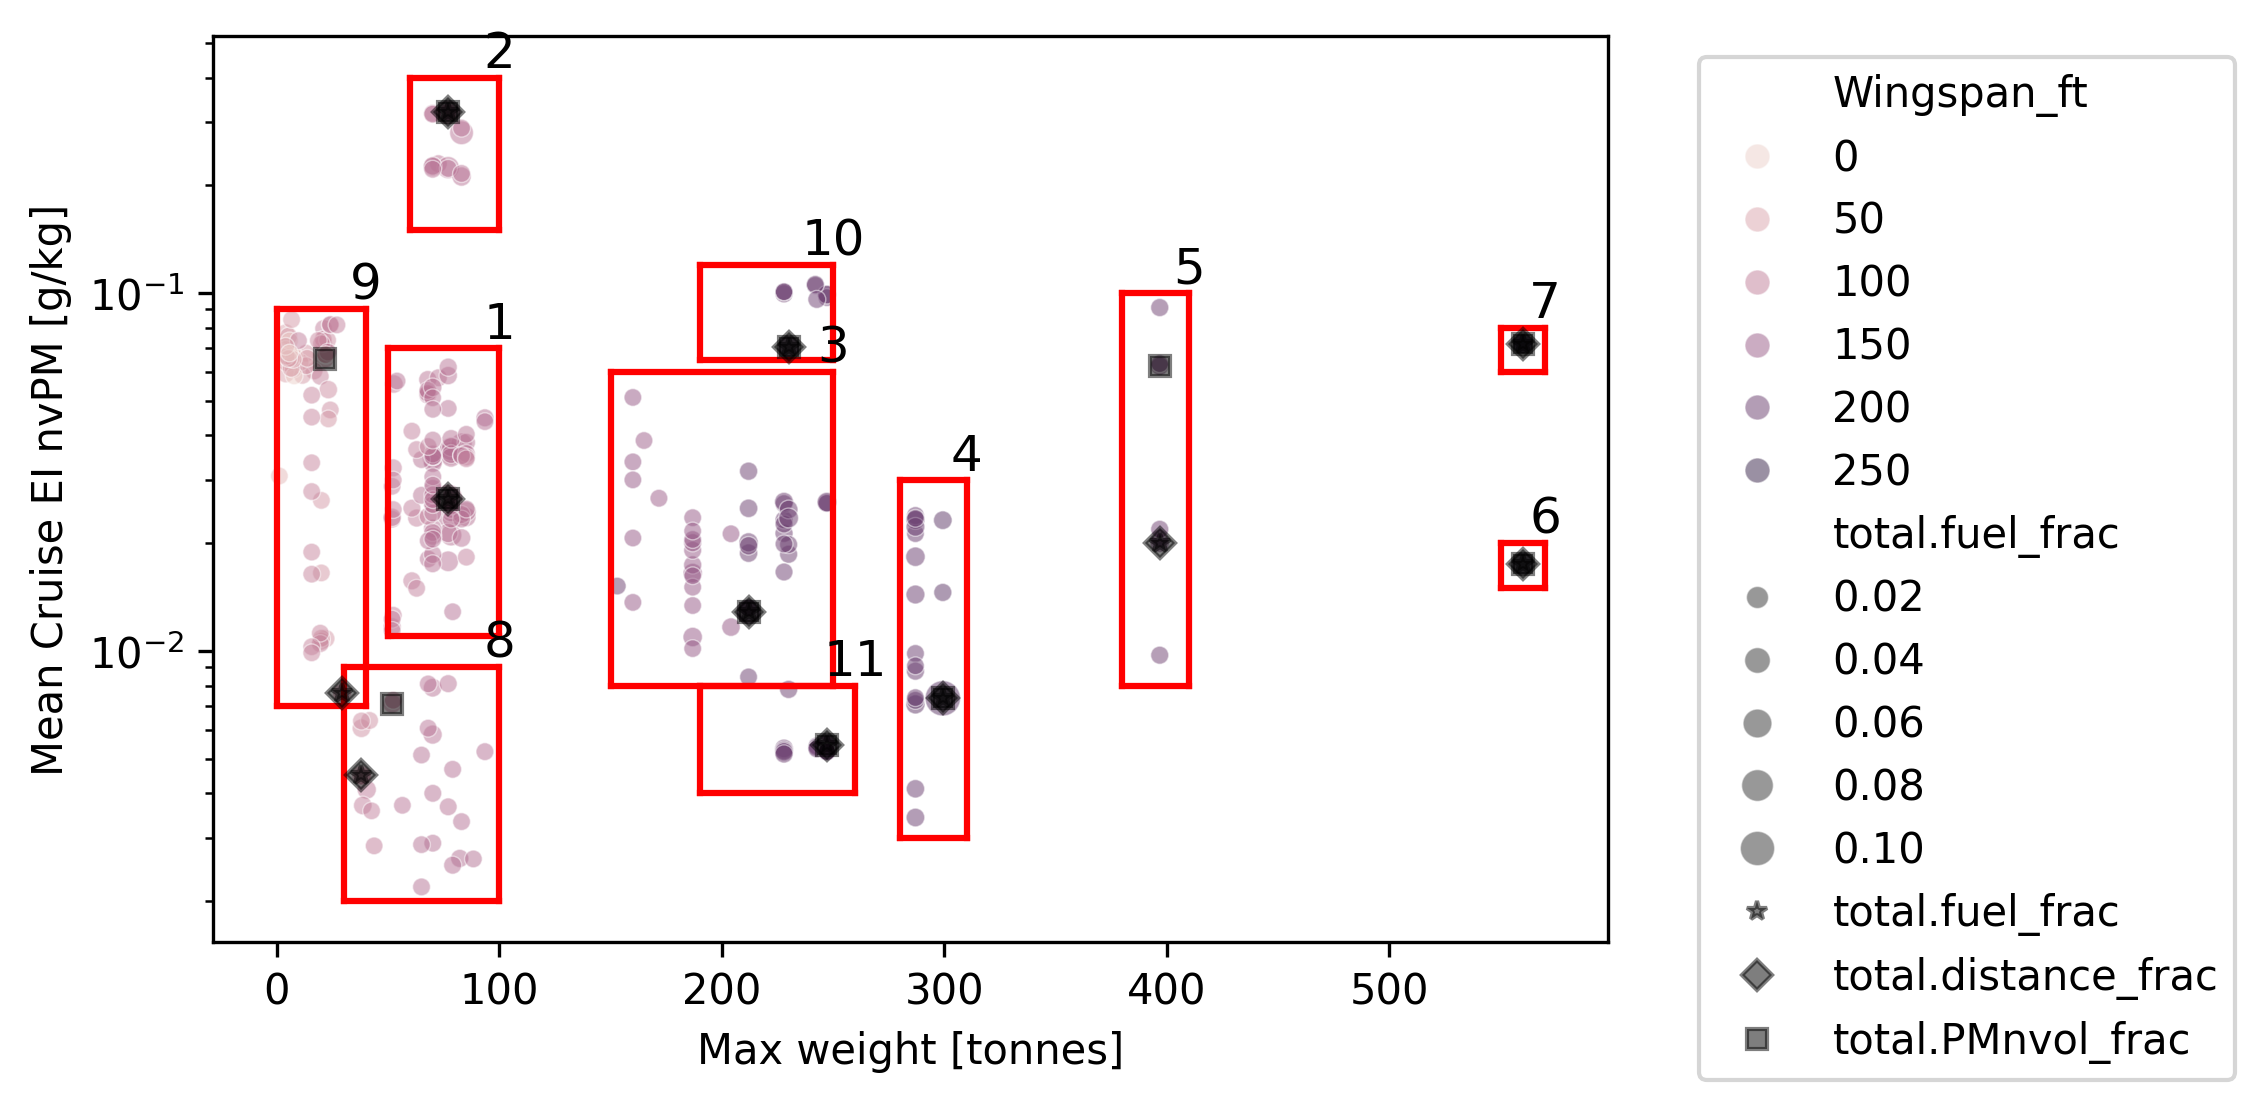

In [ ]:
fig, ax = plt.subplots(dpi=300)
is_baseplot_only = 0
x_param = 'AC_maxweight(t)'
yaxis_param = 'cruise.EI_nvpm(g/kg)_mean'
hue_param = 'Wingspan_ft'
size_param = 'total.fuel_frac'

# Plot all points
sns.scatterplot(data=emissions_data_grpd, x=x_param, y=yaxis_param, hue=hue_param, size=size_param, alpha=0.5, ax=ax)

# Set legend outside of the plot
ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
ax.set_yscale('log')

if is_baseplot_only == 0:
        clusters_dict = {1: {'max_weight_lims': [50, 100], 'EI_nvpm_lims': [1.1e-2, 0.7e-1]},
                                         2: {'max_weight_lims': [60, 100], 'EI_nvpm_lims': [1.5e-1, 4e-1]},
                                         3: {'max_weight_lims': [150, 250], 'EI_nvpm_lims': [0.8e-2, 0.6e-1]},
                                         4: {'max_weight_lims': [280, 310], 'EI_nvpm_lims': [3e-3, 3e-2]},
                                         5: {'max_weight_lims': [380, 410], 'EI_nvpm_lims': [8e-3, 1e-1]},
                                         6: {'max_weight_lims': [550, 570], 'EI_nvpm_lims': [1.5e-2, 2e-2]},
                                         7: {'max_weight_lims': [550, 570], 'EI_nvpm_lims': [6e-2, 8e-2]},
                                         8: {'max_weight_lims': [30, 100], 'EI_nvpm_lims': [2e-3, 9e-3]},
                                         9: {'max_weight_lims': [0, 40], 'EI_nvpm_lims': [7e-3, 9e-2]},
                                         10: {'max_weight_lims': [190, 250], 'EI_nvpm_lims': [6.5e-2, 1.2e-1]},
                                         11: {'max_weight_lims': [190, 260], 'EI_nvpm_lims': [4e-3, 0.8e-2]}
                                        }

        # Create a dataframe with info for each cluster
        columns = ['max_weight_min', 'max_weight_max', 'EI_nvpm_min', 'EI_nvpm_max',
                           'total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac']

        cluster_df = pd.DataFrame(columns=columns)
        emissions_data_grpd['cluster'] = np.nan

        for cluster in clusters_dict:
                # Add clusters to the graph
                max_weight_lims = clusters_dict[cluster]['max_weight_lims']
                EI_nvpm_lims = clusters_dict[cluster]['EI_nvpm_lims']

                # Add the cluster to the emissions_data_grpd dataframe
                locs = ((emissions_data_grpd['AC_maxweight(t)'] > max_weight_lims[0]) &
                                (emissions_data_grpd['AC_maxweight(t)'] < max_weight_lims[1]) &
                                (emissions_data_grpd['cruise.EI_nvpm(g/kg)_mean'] > EI_nvpm_lims[0]) &
                                (emissions_data_grpd['cruise.EI_nvpm(g/kg)_mean'] < EI_nvpm_lims[1]))

                emissions_data_grpd.loc[locs, 'cluster'] = cluster

                # Fraction of fuel burn in this range
                temp_df = emissions_data_grpd[locs].aggregate(sum)

                cluster_df.loc[cluster, 'max_weight_min'] = max_weight_lims[0]
                cluster_df.loc[cluster, 'max_weight_max'] = max_weight_lims[1]
                cluster_df.loc[cluster, 'EI_nvpm_min'] = EI_nvpm_lims[0]
                cluster_df.loc[cluster, 'EI_nvpm_max'] = EI_nvpm_lims[1]
                cluster_df.loc[cluster, 'total.fuel_frac'] = temp_df['total.fuel_frac']
                cluster_df.loc[cluster, 'total.distance_frac'] = temp_df['total.distance_frac']
                cluster_df.loc[cluster, 'total.PMnvol_frac'] = temp_df['total.PMnvol_frac']

                # Plot the bounding box of the max_weight_lims and EI_nvpm_lims
                xmin, xmax = max_weight_lims
                ymin, ymax = EI_nvpm_lims
                ax.plot([xmin, xmax], [ymin, ymin], 'r-')  # Left side
                ax.plot([xmax, xmax], [ymin, ymax], 'r-')  # Right side
                ax.plot([xmin, xmax], [ymax, ymax], 'r-')  # Top side
                ax.plot([xmin, xmin], [ymin, ymax], 'r-')  # Bottom side

                # Add label top right just outside the cluster on the plot
                ax.text((xmax), (ymax), str(cluster), fontsize=12, ha='center', va='bottom')

                ax.set_xlabel('Max weight [tonnes]')
                ax.set_ylabel('Mean Cruise EI nvPM [g/kg]')

                # Plot the aircraft with the highest contribution
                marker_dict = {'total.fuel_frac':'*', 'total.distance_frac':'D', 'total.PMnvol_frac':'s'}
                for var in ['total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac']:
                        emit_tmp = emissions_data_grpd[emissions_data_grpd['cluster']==cluster].sort_values(var, ascending=False).head(1)
                        marker_1 = ax.plot(emit_tmp['AC_maxweight(t)'], emit_tmp['cruise.EI_nvpm(g/kg)_mean'], c='k', marker=marker_dict[var], markersize=5, linestyle='None', label=var, alpha=0.5)

                        if cluster == 1:
                                legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
                                handles, labels = legend.legendHandles, legend.get_texts()

                                new_handles = [marker_1]
                                new_labels = [var]

                                all_handles = handles + new_handles
                                all_labels = [label.get_text() for label in labels] + new_labels

                                ax.legend(all_handles, all_labels,bbox_to_anchor=(1.05, 1), loc=2) 

                ax.legend(all_handles, all_labels,bbox_to_anchor=(1.05, 1), loc=2) 

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


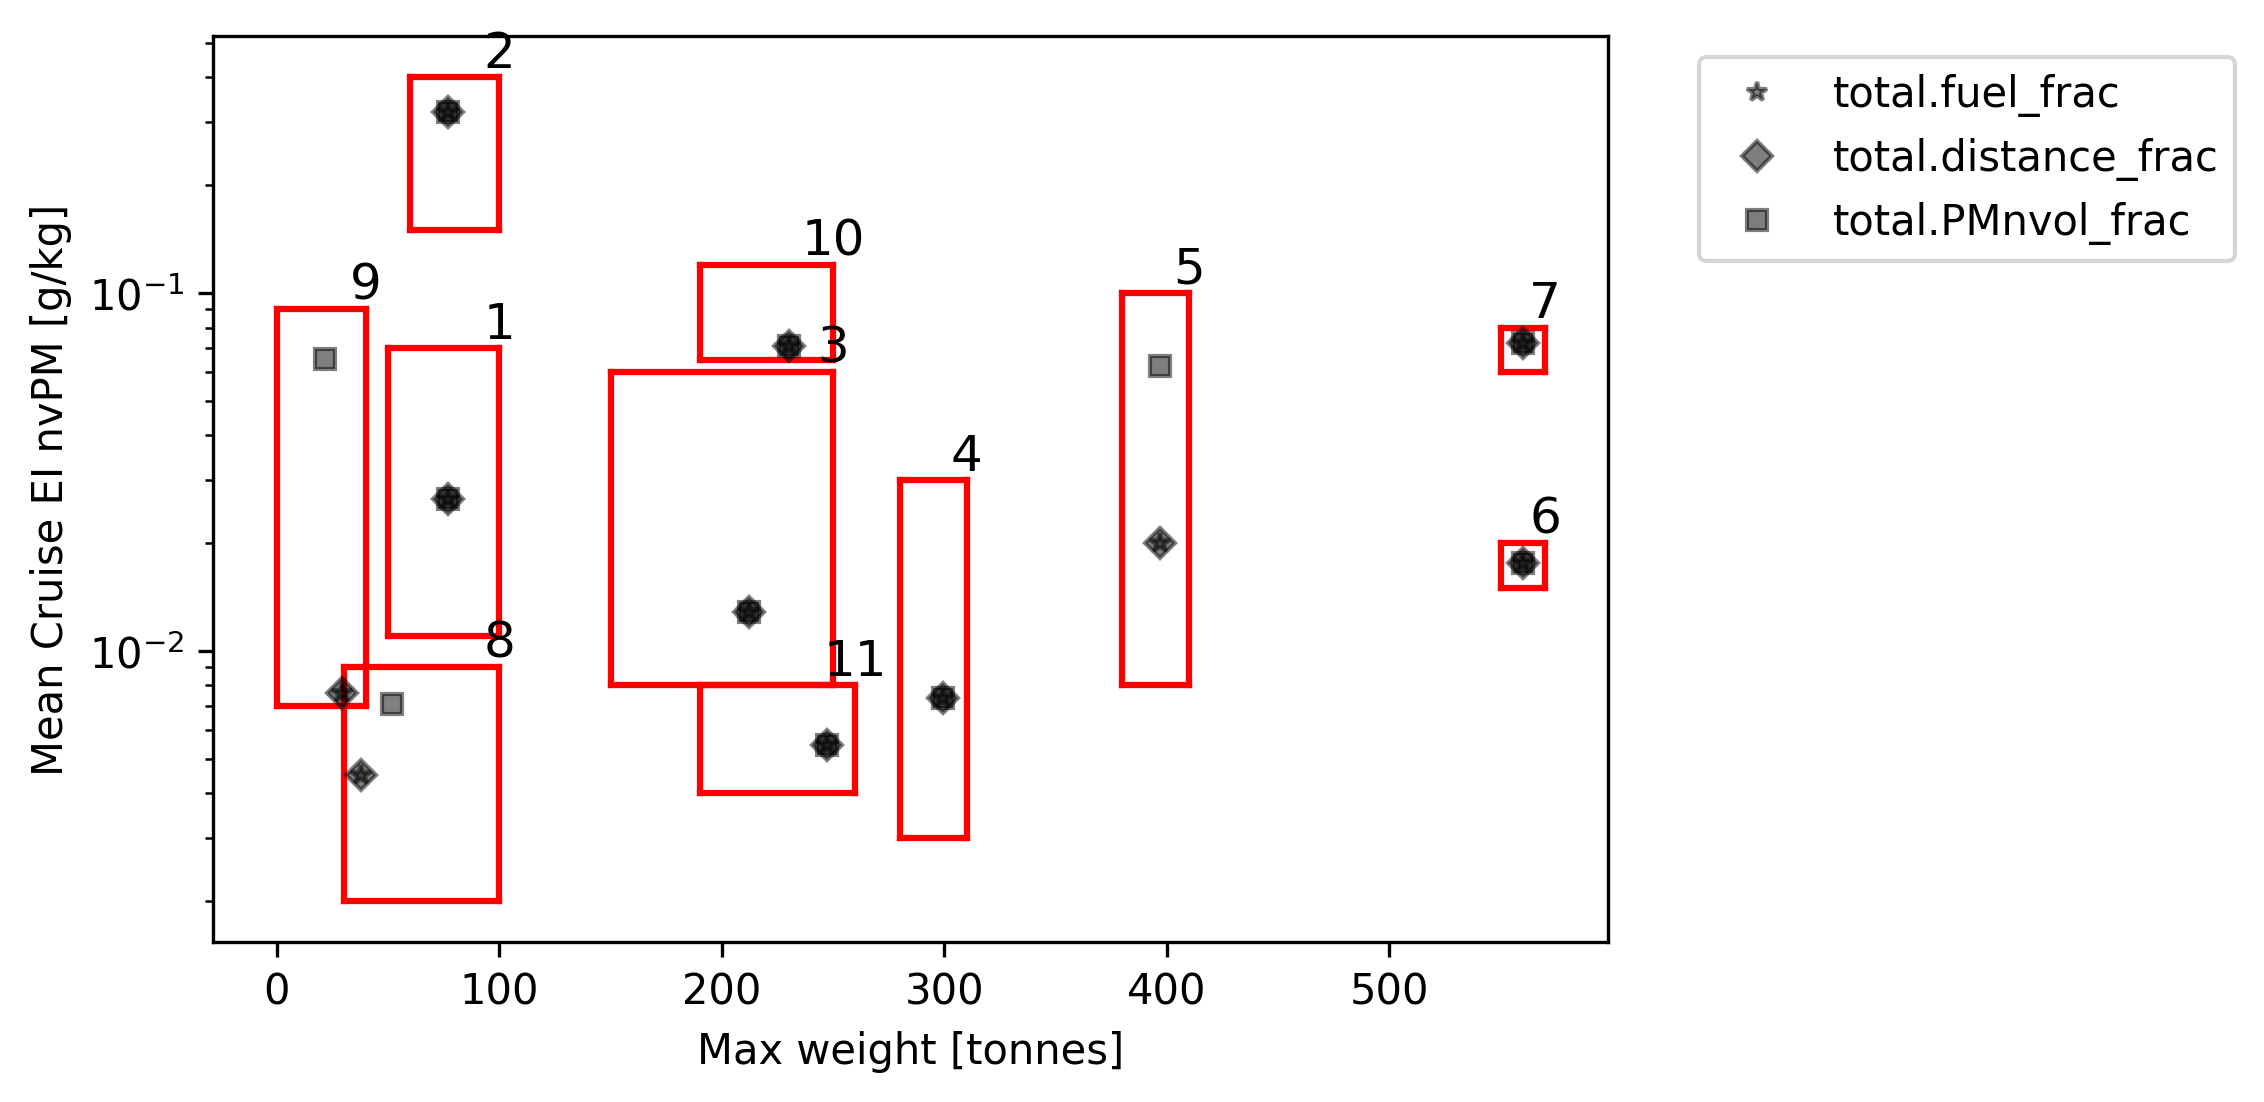

In [ ]:
fig, ax = plt.subplots(dpi=300)
is_baseplot_only = 0
x_param = 'AC_maxweight(t)'
yaxis_param = 'cruise.EI_nvpm(g/kg)_mean'
hue_param = 'Wingspan_ft'
size_param = 'total.fuel_frac'

# Set legend outside of the plot
ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
ax.set_yscale('log')

if is_baseplot_only == 0:
    clusters_dict = {1: {'max_weight_lims': [50, 100], 'EI_nvpm_lims': [1.1e-2, 0.7e-1]},
                     2: {'max_weight_lims': [60, 100], 'EI_nvpm_lims': [1.5e-1, 4e-1]},
                     3: {'max_weight_lims': [150, 250], 'EI_nvpm_lims': [0.8e-2, 0.6e-1]},
                     4: {'max_weight_lims': [280, 310], 'EI_nvpm_lims': [3e-3, 3e-2]},
                     5: {'max_weight_lims': [380, 410], 'EI_nvpm_lims': [8e-3, 1e-1]},
                     6: {'max_weight_lims': [550, 570], 'EI_nvpm_lims': [1.5e-2, 2e-2]},
                     7: {'max_weight_lims': [550, 570], 'EI_nvpm_lims': [6e-2, 8e-2]},
                     8: {'max_weight_lims': [30, 100], 'EI_nvpm_lims': [2e-3, 9e-3]},
                     9: {'max_weight_lims': [0, 40], 'EI_nvpm_lims': [7e-3, 9e-2]},
                     10: {'max_weight_lims': [190, 250], 'EI_nvpm_lims': [6.5e-2, 1.2e-1]},
                     11: {'max_weight_lims': [190, 260], 'EI_nvpm_lims': [4e-3, 0.8e-2]}
                    }

    # Create a dataframe with info for each cluster
    columns = ['max_weight_min', 'max_weight_max', 'EI_nvpm_min', 'EI_nvpm_max',
               'total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac']

    cluster_df = pd.DataFrame(columns=columns)
    emissions_data_grpd['cluster'] = np.nan

    for cluster in clusters_dict:
        # Add clusters to the graph
        max_weight_lims = clusters_dict[cluster]['max_weight_lims']
        EI_nvpm_lims = clusters_dict[cluster]['EI_nvpm_lims']

        # Add the cluster to the emissions_data_grpd dataframe
        locs = ((emissions_data_grpd['AC_maxweight(t)'] > max_weight_lims[0]) &
                (emissions_data_grpd['AC_maxweight(t)'] < max_weight_lims[1]) &
                (emissions_data_grpd['cruise.EI_nvpm(g/kg)_mean'] > EI_nvpm_lims[0]) &
                (emissions_data_grpd['cruise.EI_nvpm(g/kg)_mean'] < EI_nvpm_lims[1]))

        emissions_data_grpd.loc[locs, 'cluster'] = cluster

        # Fraction of fuel burn in this range
        temp_df = emissions_data_grpd[locs].aggregate(sum)

        cluster_df.loc[cluster, 'max_weight_min'] = max_weight_lims[0]
        cluster_df.loc[cluster, 'max_weight_max'] = max_weight_lims[1]
        cluster_df.loc[cluster, 'EI_nvpm_min'] = EI_nvpm_lims[0]
        cluster_df.loc[cluster, 'EI_nvpm_max'] = EI_nvpm_lims[1]
        cluster_df.loc[cluster, 'total.fuel_frac'] = temp_df['total.fuel_frac']
        cluster_df.loc[cluster, 'total.distance_frac'] = temp_df['total.distance_frac']
        cluster_df.loc[cluster, 'total.PMnvol_frac'] = temp_df['total.PMnvol_frac']

        # Plot the bounding box of the max_weight_lims and EI_nvpm_lims
        xmin, xmax = max_weight_lims
        ymin, ymax = EI_nvpm_lims
        ax.plot([xmin, xmax], [ymin, ymin], 'r-')  # Left side
        ax.plot([xmax, xmax], [ymin, ymax], 'r-')  # Right side
        ax.plot([xmin, xmax], [ymax, ymax], 'r-')  # Top side
        ax.plot([xmin, xmin], [ymin, ymax], 'r-')  # Bottom side

        # Add label top right just outside the cluster on the plot
        ax.text((xmax), (ymax), str(cluster), fontsize=12, ha='center', va='bottom')

        ax.set_xlabel('Max weight [tonnes]')
        ax.set_ylabel('Mean Cruise EI nvPM [g/kg]')

        # Plot the aircraft with the highest contribution
        marker_dict = {'total.fuel_frac':'*', 'total.distance_frac':'D', 'total.PMnvol_frac':'s'}
        for var in ['total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac']:
            emit_tmp = emissions_data_grpd[emissions_data_grpd['cluster']==cluster].sort_values(var, ascending=False).head(1)
            marker_1 = ax.plot(emit_tmp['AC_maxweight(t)'], emit_tmp['cruise.EI_nvpm(g/kg)_mean'], c='k', marker=marker_dict[var], markersize=5, linestyle='None', label=var, alpha=0.5)

            if cluster == 1:
                legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
                handles, labels = legend.legendHandles, legend.get_texts()

                new_handles = [marker_1]
                new_labels = [var]

                all_handles = handles + new_handles
                all_labels = [label.get_text() for label in labels] + new_labels

                ax.legend(all_handles, all_labels,bbox_to_anchor=(1.05, 1), loc=2) 

        ax.legend(all_handles, all_labels,bbox_to_anchor=(1.05, 1), loc=2) 

plt.show()


## Weighting fuel burn with age penalty function

In [ ]:
# Define a function to determine the body type based on max weight
def determine_body_type(max_weight):
    if max_weight < 170:
        return 'Narrow-body'
    else:
        return 'Wide-body'
    
def age_weighted_fuel_frac(row, alpha):
    return row['total.fuel_frac']*np.exp(-alpha*row['Age'])

plot_data = pd.DataFrame(columns=['Aircraft.Type', 'total.PMnvol_frac', 'total.distance_frac', 'total.fuel_frac', 'AC_maxweight', 'cluster'])

# Add a column called body.type that is populated by a function call to determine body type
plot_data['body.type'] = plot_data['AC_maxweight'].apply(determine_body_type)

In [ ]:
# NEED AGES OF AIRCRAFT AS COLUMN IN plot_data NAMED 'Age'

# Weight fuel burn with age-penalty
retire_age_wb = 30 # years
retire_age_nb = 25 # years

alpha_wide_body = -np.log(0.01)/retire_age_wb
alpha_narrow_body = -np.log(0.01)/retire_age_nb

# Make a copy of plot_data
plot_data_age_weighted = plot_data.copy()

# Filter out entries where Seats_max is less than 100 (no regional jets)
plot_data_age_weighted = plot_data[emissions_data_grpd['Seats_max'] >= 100]

# Recalculate fuel burn with age penalty
if plot_data_age_weighted['body.type'] == 'Wide-body':
    plot_data_age_weighted['total.fuel_frac'] = age_weighted_fuel_frac(plot_data_age_weighted, alpha_wide_body)
else:
    plot_data_age_weighted['total.fuel_frac'] = age_weighted_fuel_frac(plot_data_age_weighted, alpha_narrow_body)

NameError: name 'np' is not defined

## Plot narrow body vs wide body split

In [ ]:
## Make scatter plots of the aircraft types
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
is_baseplot_only = 0
x_param = 'AC_maxweight(t)'
yaxis_param = 'cruise.EI_nvpm(g/kg)_mean'
hue_param = 'Wingspan_ft'
size_param = 'total.fuel_frac'

# set legend below the plot
ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=3)
ax.set_yscale('log')

if is_baseplot_only == 0:
    clusters_dict = {1: {'max_weight_lims': [50, 100], 'EI_nvpm_lims': [1.1e-2, 0.7e-1]},
                    2: {'max_weight_lims': [60, 100], 'EI_nvpm_lims': [1.5e-1, 4e-1]},
                    3: {'max_weight_lims': [150, 250], 'EI_nvpm_lims': [0.8e-2, 0.6e-1]},
                    4: {'max_weight_lims': [280, 310], 'EI_nvpm_lims': [3e-3, 3e-2]},
                    5: {'max_weight_lims': [380, 410], 'EI_nvpm_lims': [8e-3, 1e-1]},
                    6: {'max_weight_lims': [550, 570], 'EI_nvpm_lims': [1.5e-2, 2e-2]},
                    7: {'max_weight_lims': [550, 570], 'EI_nvpm_lims': [6e-2, 8e-2]},
                    8: {'max_weight_lims': [30, 100], 'EI_nvpm_lims': [2e-3, 9e-3]},
                    9: {'max_weight_lims': [0, 40], 'EI_nvpm_lims': [7e-3, 9e-2]},
                    10: {'max_weight_lims': [190, 250], 'EI_nvpm_lims': [6.5e-2, 1.2e-1]},
                    11: {'max_weight_lims': [190, 260], 'EI_nvpm_lims': [4e-3, 0.8e-2]}
                    }

    # create a dataframe with info for each cluster
    columns = ['max_weight_min', 'max_weight_max', 'EI_nvpm_min', 'EI_nvpm_max',
            'total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac', 'Aircraft.Type']

    cluster_df = pd.DataFrame(columns=columns)
    emissions_data_grpd['cluster'] = np.nan

    plot_data = pd.DataFrame(columns=['Aircraft.Type', 'total.PMnvol_frac', 'total.distance_frac', 'total.fuel_frac', 'AC_maxweight', 'cluster'])

    for cluster in clusters_dict:
        # add clusters to the graph
        max_weight_lims = clusters_dict[cluster]['max_weight_lims']
        EI_nvpm_lims = clusters_dict[cluster]['EI_nvpm_lims']

        # add the cluster to the emissions_data_grpd dataframe
        locs = ((emissions_data_grpd['AC_maxweight(t)'] > max_weight_lims[0]) &
                            (emissions_data_grpd['AC_maxweight(t)'] < max_weight_lims[1])&
                            (emissions_data_grpd['cruise.EI_nvpm(g/kg)_mean'] > EI_nvpm_lims[0]) &
                            (emissions_data_grpd['cruise.EI_nvpm(g/kg)_mean'] < EI_nvpm_lims[1]))

        emissions_data_grpd.loc[locs, 'cluster'] = cluster

        # fraction of fuel burn in this range
        temp_df = (emissions_data_grpd[locs].aggregate(sum))

        cluster_df.loc[cluster, 'max_weight_min'] = max_weight_lims[0]
        cluster_df.loc[cluster, 'max_weight_max'] = max_weight_lims[1]
        cluster_df.loc[cluster, 'EI_nvpm_min'] = EI_nvpm_lims[0]
        cluster_df.loc[cluster, 'EI_nvpm_max'] = EI_nvpm_lims[1]
        cluster_df.loc[cluster, 'total.fuel_frac'] = temp_df['total.fuel_frac']
        cluster_df.loc[cluster, 'total.distance_frac'] = temp_df['total.distance_frac']
        cluster_df.loc[cluster, 'total.PMnvol_frac'] = temp_df['total.PMnvol_frac'] / temp_df['total.fuel_frac']  # Normalize by total.fuel_frac
        
        # Format the aircraft type
        aircraft_types = emissions_data_grpd[locs]['Aircraft.Type'].unique()
        formatted_aircraft_types = []
        for aircraft_type in aircraft_types:
            parts = aircraft_type.split('_')
            if len(parts) > 2:
                label = '_'.join(parts[1:3])
            else:
                label = aircraft_type
            label = label.replace('_', ' ').replace('SelectOneUpgradePackage', '')
            formatted_aircraft_types.append(label)
        cluster_df.loc[cluster, 'Aircraft.Type'] = ', '.join(formatted_aircraft_types)

        # plot the bounding box of the max_weight_lims and EI_nvpm_lims
        xmin, xmax = max_weight_lims
        ymin, ymax = EI_nvpm_lims
        ax.plot([xmin, xmax], [ymin, ymin], 'r-')  # Left side
        ax.plot([xmax, xmax], [ymin, ymax], 'r-')  # Right side
        ax.plot([xmin, xmax], [ymax, ymax], 'r-')  # Top side
        ax.plot([xmin, xmin], [ymin, ymax], 'r-')  # Bottom side

        # add label top right just outside the cluster on the plot
        ax.text((xmax), (ymax), str(cluster), fontsize=12, ha='center', va='bottom')

        ax.set_xlabel('Max weight [tonnes]', fontsize=14)
        ax.set_ylabel('Mean Cruise EI nvPM [g/kg]', fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=12)

        # plot the aircraft with the highest contribution
        marker_dict = {'total.fuel_frac':'*', 'total.distance_frac':'D', 'total.PMnvol_frac':'s'}
        label_dict = {'total.fuel_frac':'Total Fuel Fraction', 'total.distance_frac':'Total Distance Fraction', 'total.PMnvol_frac':'Total PM Fraction (V)'}
        for var in ['total.fuel_frac', 'total.distance_frac', 'total.PMnvol_frac']:
            emit_tmp = emissions_data_grpd[emissions_data_grpd['cluster']==cluster].sort_values(var, ascending=False).head(1)
            marker_1 = ax.plot(emit_tmp['AC_maxweight(t)'], emit_tmp['cruise.EI_nvpm(g/kg)_mean'], c='k', marker=marker_dict[var], markersize=5, linestyle='None', label=label_dict[var], alpha=0.5)

            # Annotate the aircraft type
            for i, row in emit_tmp.iterrows():
                aircraft_type = row['Aircraft.Type']
                parts = aircraft_type.split('_')
                if len(parts) > 2:
                    label = '_'.join(parts[1:3])
                else:
                    label = aircraft_type
                label = label.replace('_', ' ').replace('SelectOneUpgradePackage', '')
                ax.annotate(label, (row['AC_maxweight(t)'], row['cruise.EI_nvpm(g/kg)_mean']), fontsize=10, ha='right')

            if cluster == 1:
                legend = ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=3)
                handles, labels = legend.legendHandles, legend.get_texts()

                new_handles = [marker_1]
                new_labels = [label_dict[var]]

                all_handles = handles + new_handles
                all_labels = [label.get_text() for label in labels] + new_labels

                ax.legend(all_handles, all_labels, bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=3) 

            # Append the data to the plot_data dataframe
            emit_tmp = emit_tmp[['Aircraft.Type', 'cruise.EI_nvpm(g/kg)_mean', 'total.PMnvol_frac', 'total.distance_frac', 'total.fuel_frac', 'AC_maxweight(t)']].rename(columns={'AC_maxweight(t)': 'AC_maxweight'})
            emit_tmp['cluster'] = cluster
            plot_data = pd.concat([plot_data, emit_tmp])

        ax.legend(all_handles, all_labels, bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=3) 

    # Drop duplicates from plot_data
    plot_data = plot_data.drop_duplicates()

plt.show()


In [ ]:
fig, ax = plt.subplots(dpi=300)

# Set y-axis to log scale
ax.set_yscale('log')
ax.set_xlabel('Body Type')
ax.set_ylabel('Cruise EI nvPM [g/kg]')

# Create the swarm plot
swarm = sns.swarmplot(x='body.type', y='cruise.EI_nvpm(g/kg)_mean', data=plot_data, dodge=True, size=10, linewidth=0.5, ax=ax, color='black', edgecolor='red')

# Change the color of the marker to yellow if the cluster is 1, 2, or 4
for cluster in [1, 2, 4]:
    cluster_data = plot_data[plot_data['cluster'] == cluster]
    sns.swarmplot(x='body.type', y='cruise.EI_nvpm(g/kg)_mean', data=cluster_data, dodge=True, size=10, linewidth=0.5, ax=ax, color='yellow', edgecolor='red')

# Annotate each point with its respective cluster
# Save the offsets imposed by using the swarmplot so we can use them to properly center the labels when plotting
offsets1 = swarm.collections[0].get_offsets()
offsets2 = swarm.collections[1].get_offsets()

for i, (x, y) in enumerate(offsets1):
    narrow_body_data = plot_data[plot_data['body.type'] == 'Narrow-body']
    row = narrow_body_data.iloc[i]
    color = 'black' if row['cluster'] in [1, 2, 4] else 'white'
    ax.annotate(row['cluster'], (1.8*x, y), fontsize=7, ha='center', va='center', color=color)

for i, (x, y) in enumerate(offsets2):
    wide_body_data = plot_data[plot_data['body.type'] == 'Wide-body']
    row = wide_body_data.iloc[i]
    color = 'black' if row['cluster'] in [1, 2, 4] else 'white'
    
    if row['cluster'] == 7:
        ax.annotate(row['cluster'], (x + 0.02, y), fontsize=7, ha='center', va='center', color=color)
    elif row['cluster'] == 10:
        if x < 1:
            ax.annotate(row['cluster'], (x-0.02 , y), fontsize=7, ha='center', va='center', color=color)
    elif row['cluster'] == 5:
        print(x, y)
        if x > 0.99:
            ax.annotate(row['cluster'], (x , y), fontsize=7, ha='center', va='center', color=color)
        else:
            ax.annotate(row['cluster'], (x-0.02 , y), fontsize=7, ha='center', va='center', color=color)
    else:
        ax.annotate(row['cluster'], (x, y), fontsize=7, ha='center', va='center', color=color)

plt.show()
